Notebook to generate the figures in the readme.md

In [1]:
from viz import * 
import numpy as np
import pandas as pd
import seaborn as sns
import geopandas as gpd 
import matplotlib as mpl
import matplotlib.pyplot as plt 
from epiweeks import Week 
from aux_func import get_data, color_palette, rename_models

# Definir a cor das bordas (spines) como cinza
mpl.rcParams['axes.edgecolor'] = 'gray'

# Definir a cor das linhas dos ticks maiores e menores como cinza
mpl.rcParams['xtick.color'] = 'gray'
mpl.rcParams['ytick.color'] = 'gray'
mpl.rcParams['xtick.labelcolor'] = 'black'
mpl.rcParams['ytick.labelcolor'] = 'black'
plt.rcParams['axes.labelsize'] = 16 # Axis labels
plt.rcParams['xtick.labelsize'] = 14  # X-axis tick labels
plt.rcParams['ytick.labelsize'] = 14  # Y-axis tick labels
plt.rcParams['font.size'] = 16  # General font size
FONT = 12

In [2]:
challenge = 'chik_city'

In [3]:
df_dengue = get_data(challenge)
df_dengue.date = pd.to_datetime(df_dengue.date)

df_dengue.head()

,date,adm_2,casos
0,2013-12-29,3143302,0
1,2013-12-29,1716109,0
2,2013-12-29,1721000,0
3,2013-12-29,3119401,0
4,2013-12-29,5102637,0


In [4]:
df_preds = pd.read_csv(f'./predictions/predictions_all_models_{challenge}.csv.gz', index_col = 'Unnamed: 0')
df_preds.date = pd.to_datetime(df_preds.date)
df_preds['model'] = df_preds['model'].replace(rename_models)
df_preds.head()

,date,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,adm_2,id,validation,wis,model
0,2022-10-09,25.725779,40.048709,51.521559,71.846609,97.558066,139.275377,213.218291,275.721368,339.686145,2211001,13242,1,24.86,EMAP_SARIMAX
1,2022-10-16,21.174558,30.370234,38.414624,60.509652,89.745516,132.868671,200.665062,269.239226,320.662330,2211001,13242,1,24.86,EMAP_SARIMAX
2,2022-10-23,14.875249,21.505565,30.849059,50.225775,80.677850,131.207909,202.387555,268.993745,326.896074,2211001,13242,1,24.86,EMAP_SARIMAX
3,2022-10-30,12.338729,17.735987,25.616908,43.639132,74.259948,124.076144,209.722579,278.453083,352.552289,2211001,13242,1,24.86,EMAP_SARIMAX
4,2022-11-06,10.319616,14.082060,20.680341,38.656206,68.720645,126.590559,229.344991,326.112375,430.224896,2211001,13242,1,24.86,EMAP_SARIMAX


In [5]:
df_preds.model.unique()

<ArrowStringArray>
['EMAP_SARIMAX', 'NUS-CERM', 'EMAP_LSTM', 'EMAP_XGB', 'EMAP_PROPHET',
 'PURDUE']
Length: 6, dtype: str

In [6]:
df_muni = gpd.read_file('../imdc_2026/data/shape_muni.gpkg')
df_muni = df_muni.loc[df_muni.geocode.isin(df_dengue.adm_2)]
df_muni.head(15)

,geocode,geocode_name,uf,uf_code,geometry
401,1716109,Paraíso do Tocantins,TO,17,"MULTIPOLYGON (((-48.8843 -10.31861, -48.8797 -..."
443,1721000,Palmas,TO,17,"MULTIPOLYGON (((-48.3034 -10.41476, -48.29667 ..."
882,2211001,Teresina,PI,22,"MULTIPOLYGON (((-42.80437 -5.20656, -42.80891 ..."
2214,2931350,Teixeira de Freitas,BA,29,"MULTIPOLYGON (((-39.72129 -17.28062, -39.73264..."
2456,3119401,Coronel Fabriciano,MG,31,"MULTIPOLYGON (((-42.6245 -19.53288, -42.61952 ..."
2743,3143302,Montes Claros,MG,31,"MULTIPOLYGON (((-43.75228 -16.49649, -43.75002..."
3980,4104808,Cascavel,PR,41,"MULTIPOLYGON (((-53.33281 -25.36348, -53.32708..."
4601,4219507,Xanxerê,SC,42,"MULTIPOLYGON (((-52.31491 -26.86693, -52.31477..."
5203,5102637,Campo Novo do Parecis,MT,51,"MULTIPOLYGON (((-57.54317 -13.58204, -57.53828..."
5219,5103403,Cuiabá,MT,51,"MULTIPOLYGON (((-55.70994 -15.70483, -55.68091..."


In [7]:
df_rank = pd.read_csv(f'predictions/rank_ratio_{challenge}.csv')

df_rank['model'] = df_rank['model'].replace(rename_models)

df_rank['rank'] = df_rank.groupby(['validation', 'adm_2'])['wis_ratio'].rank(ascending=True, method='min')
#df_rank['region'] = df_rank['region'].replace(rename_regions)

df_rank.loc[df_rank.wis< 0.0004, 'wis' ] = 0.01

df_rank.loc[df_rank.wis_ratio< 0.0004, 'wis_ratio' ] = 0.01

df_rank.head()

,model,adm_2,validation,wis,wis_baseline,wis_ratio,rank
0,EMAP_PROPHET,1716109,1,50.20,47.252005,1.062389,5.0
1,EMAP_PROPHET,1716109,2,0.82,11.983390,0.068428,1.0
2,EMAP_PROPHET,1716109,3,0.77,9.270000,0.083064,2.0
3,EMAP_PROPHET,1716109,4,0.79,11.670000,0.067695,2.0
4,EMAP_PROPHET,1721000,1,7.66,7.181102,1.066689,3.0


In [8]:
df_rank.loc[df_rank.wis_ratio < 0.02]

,model,adm_2,validation,wis,wis_baseline,wis_ratio,rank
28,EMAP_PROPHET,4219507,1,0.01,0.028557,0.010000,1.0
63,EMAP_SARIMAX,3143302,4,0.55,41.560000,0.013234,1.0


In [9]:
df_rank.model.unique()

<ArrowStringArray>
['EMAP_PROPHET', 'EMAP_SARIMAX', 'EMAP_LSTM', 'EMAP_XGB', 'NUS-CERM',
 'PURDUE']
Length: 6, dtype: str

In [10]:
df_rank.isnull().sum()

model           0
adm_2           0
validation      0
wis             0
wis_baseline    0
wis_ratio       0
rank            0
dtype: int64

## Plot overall performance:

EMAP_PROPHET
NUS-CERM
PURDUE


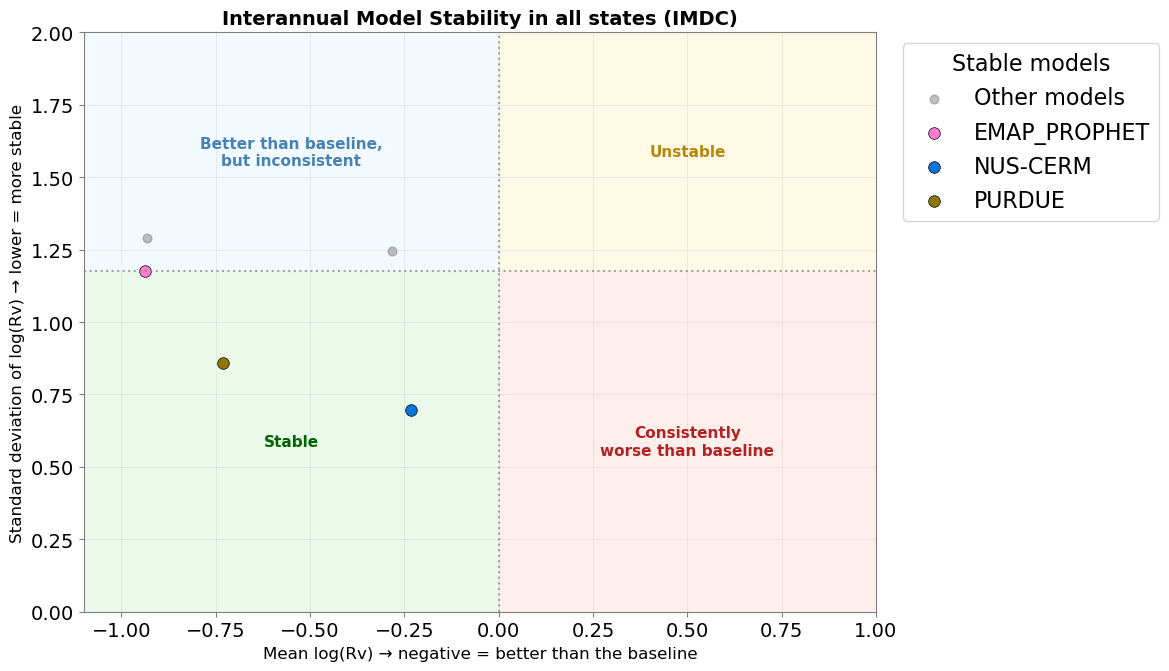

In [12]:
fig, ax, df_agg = plot_model_scatter(
    df_rank,
    rename_models=rename_models,
    baseline_model="EMAP_LSTM",
    exclude_adm1=None,
    title="Interannual Model Stability in all states (IMDC)",
    xlabel="Mean log(Rv) → negative = better than the baseline",
    ylabel="Standard deviation of log(Rv) → lower = more stable",
    xlim=(-1.1, 1),
    ylim=(0, 2),
    figsize=(12, 7),
    savepath=f'figures/scatter_stable_{challenge}.png',
    color_palette=color_palette)

### Violin plots:

/home/eduardocorrea/Documentos/analises_3rd_IMDC/viz.py:900: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


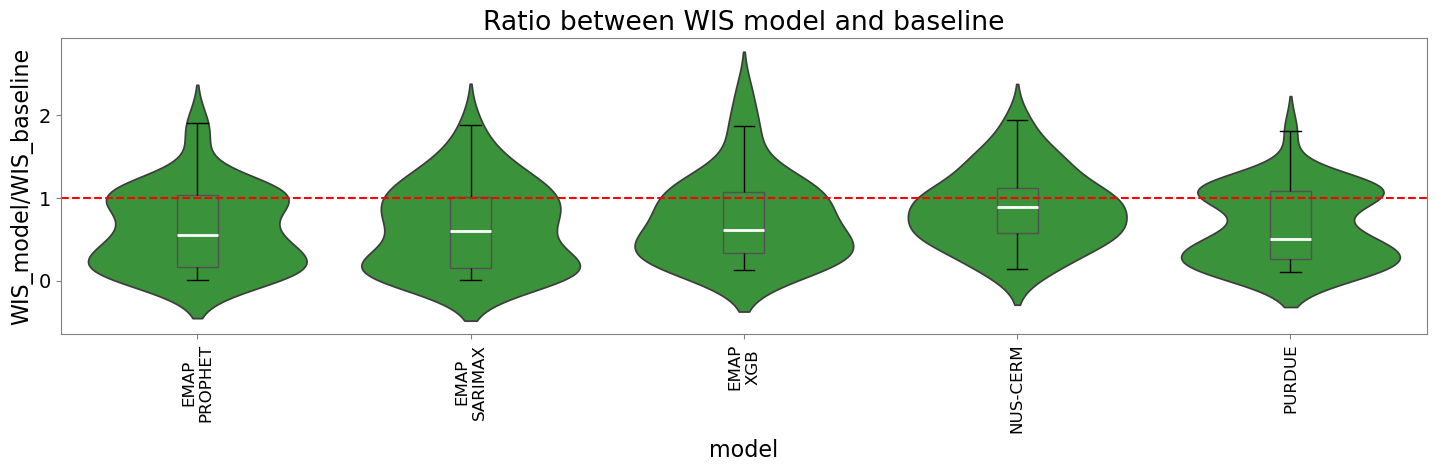

(<Figure size 1500x500 with 1 Axes>,
 <Axes: title={'center': 'Ratio between WIS model and baseline'}, xlabel='model', ylabel='WIS_model/WIS_baseline'>)

In [13]:
plot_violin(df_rank.loc[df_rank.model != 'EMAP_LSTM'], region = None, challenge=challenge)

### Heatmaps

In [14]:
df_summary = (
    df_rank
    .groupby(["adm_2", "model"], as_index=False)
    .agg(
        geometric_mean_ratio=("wis_ratio", lambda x: np.exp(np.mean(np.log(x)))),
    )
    .sort_values(["adm_2", "geometric_mean_ratio"])
)

column = 'geometric_mean_ratio'

df_summary["rank"] = (
    df_summary.groupby(["adm_2"])[[column]].rank(method="min", ascending=True)
)

df_summary = df_summary.merge(df_muni[['geocode', 'geocode_name']], left_on = 'adm_2', right_on = 'geocode' )
df_summary['uf'] = df_summary['geocode'].astype(str).str[:2].astype(int).replace(code_to_state)
df_summary['adm_2_name'] = df_summary['geocode_name'].astype(str) + ' - ' + df_summary['uf']
df_summary.head()

,adm_2,model,geometric_mean_ratio,rank,geocode,geocode_name,uf,adm_2_name
0,1716109,EMAP_SARIMAX,0.127943,1.0,1716109,Paraíso do Tocantins,TO,Paraíso do Tocantins - TO
1,1716109,EMAP_PROPHET,0.142191,2.0,1716109,Paraíso do Tocantins,TO,Paraíso do Tocantins - TO
2,1716109,PURDUE,0.204236,3.0,1716109,Paraíso do Tocantins,TO,Paraíso do Tocantins - TO
3,1716109,NUS-CERM,0.348892,4.0,1716109,Paraíso do Tocantins,TO,Paraíso do Tocantins - TO
4,1716109,EMAP_XGB,0.445957,5.0,1716109,Paraíso do Tocantins,TO,Paraíso do Tocantins - TO


In [15]:
df_summary.adm_2_name.unique()

<ArrowStringArray>
[ 'Paraíso do Tocantins - TO',                'Palmas - TO',
              'Teresina - PI',   'Teixeira de Freitas - BA',
    'Coronel Fabriciano - MG',         'Montes Claros - MG',
              'Cascavel - PR',               'Xanxerê - SC',
 'Campo Novo do Parecis - MT',                'Cuiabá - MT']
Length: 10, dtype: str

In [16]:
regions =  [ 'Cascavel - PR',               'Xanxerê - SC',
                'Coronel Fabriciano - MG',         'Montes Claros - MG',
 'Campo Novo do Parecis - MT',                'Cuiabá - MT',
    'Paraíso do Tocantins - TO',                'Palmas - TO',
              'Teresina - PI',   'Teixeira de Freitas - BA']

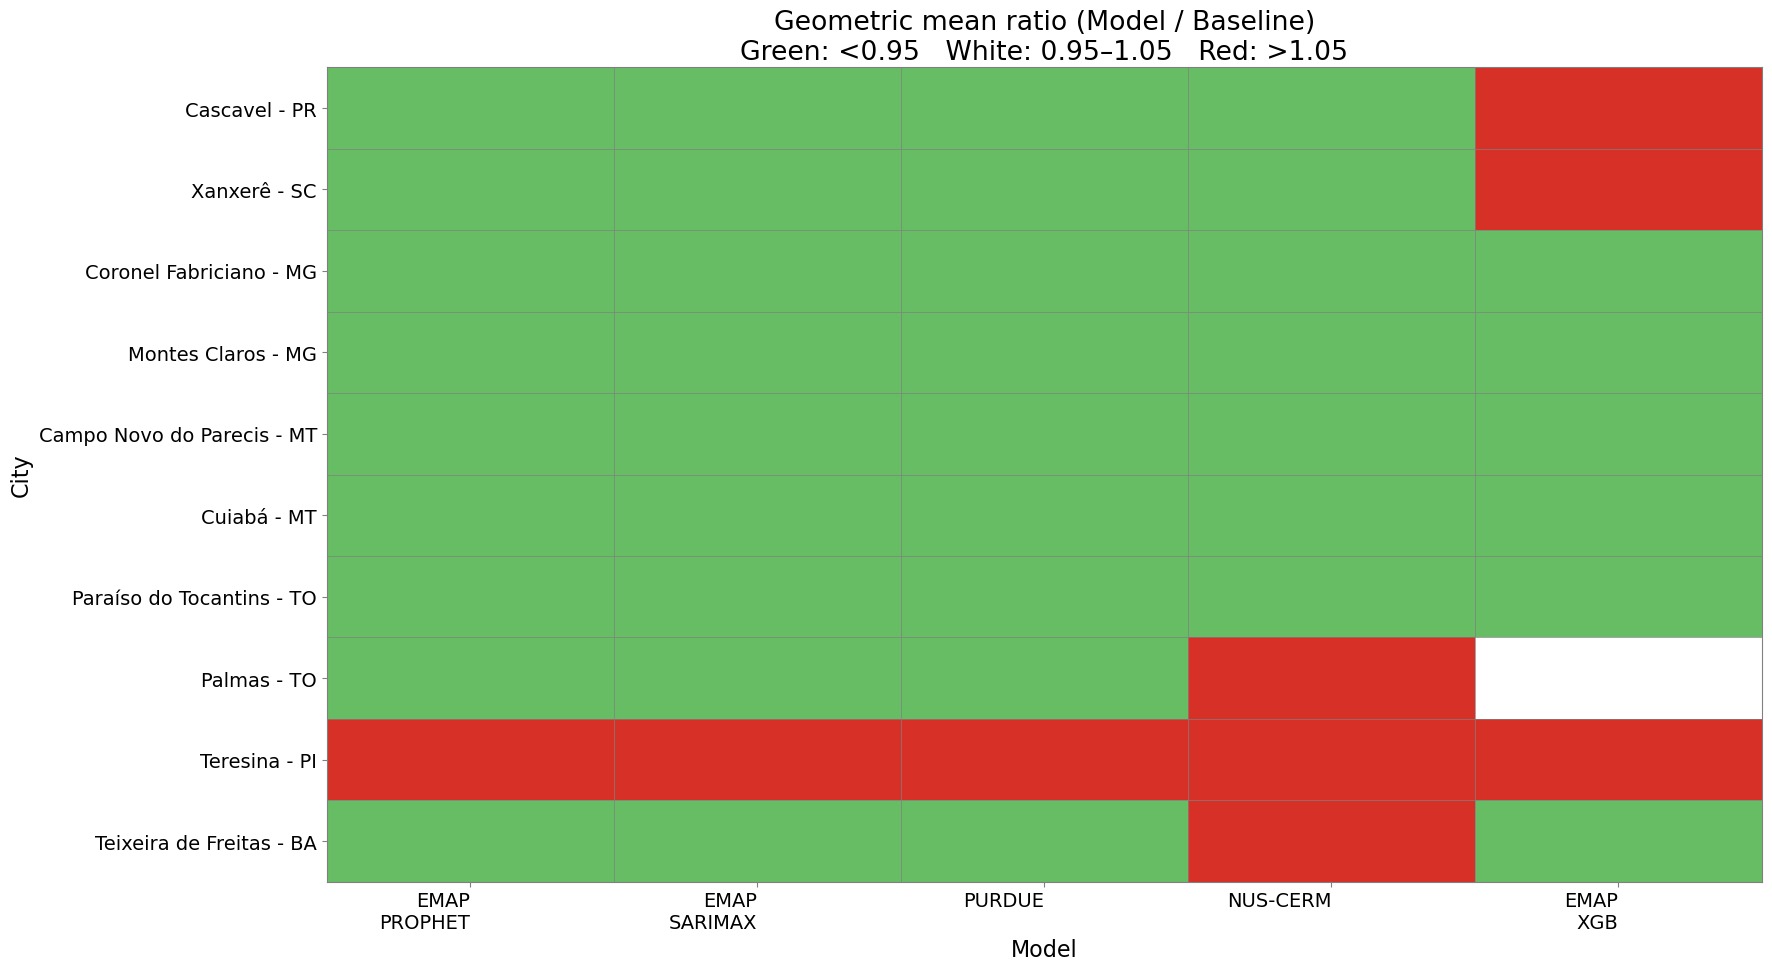

In [17]:
ranking = plot_matrix(df_summary.loc[ (df_summary.model != 'EMAP_LSTM')],
                      regions,
        figsize=(18, 10),
        challenge=challenge,
        transpose=False,
            col = 'adm_2_name',
            xlabel = 'City',
                rotation = 0, 
    region_sep = False)

In [18]:
plot_geometric_ratio_heatmap(
        df_summary.loc[ (df_summary.model != 'EMAP_LSTM')],
        regions,
        '',
        figsize=(25, 10),
        challenge=challenge,
        col = 'adm_2_name',
            ylabel = 'city',
            rotation = 0
    )

## Plots Best models by state: 

In [19]:
df_summary.model.unique()

<ArrowStringArray>
['EMAP_SARIMAX', 'EMAP_PROPHET', 'PURDUE', 'NUS-CERM', 'EMAP_XGB',
 'EMAP_LSTM']
Length: 6, dtype: str

In [20]:
df_bm_st = df_summary.loc[df_summary['rank'] ==1].rename(columns = {'model': 'best_model'})
df_bm_st['state'] = df_bm_st['adm_2'].replace(code_to_state)

df_bm_st.head()

,adm_2,best_model,geometric_mean_ratio,rank,geocode,geocode_name,uf,adm_2_name,state
0,1716109,EMAP_SARIMAX,0.127943,1.0,1716109,Paraíso do Tocantins,TO,Paraíso do Tocantins - TO,1716109
6,1721000,EMAP_PROPHET,0.503761,1.0,1721000,Palmas,TO,Palmas - TO,1721000
12,2211001,EMAP_LSTM,1.000000,1.0,2211001,Teresina,PI,Teresina - PI,2211001
18,2931350,EMAP_XGB,0.572742,1.0,2931350,Teixeira de Freitas,BA,Teixeira de Freitas - BA,2931350
24,3119401,EMAP_XGB,0.345291,1.0,3119401,Coronel Fabriciano,MG,Coronel Fabriciano - MG,3119401


In [21]:
df_bm_st[['adm_2_name', 'best_model']]

,adm_2_name,best_model
0,Paraíso do Tocantins - TO,EMAP_SARIMAX
6,Palmas - TO,EMAP_PROPHET
12,Teresina - PI,EMAP_LSTM
18,Teixeira de Freitas - BA,EMAP_XGB
24,Coronel Fabriciano - MG,EMAP_XGB
30,Montes Claros - MG,EMAP_SARIMAX
36,Cascavel - PR,EMAP_SARIMAX
42,Xanxerê - SC,EMAP_PROPHET
48,Campo Novo do Parecis - MT,EMAP_SARIMAX
54,Cuiabá - MT,EMAP_SARIMAX


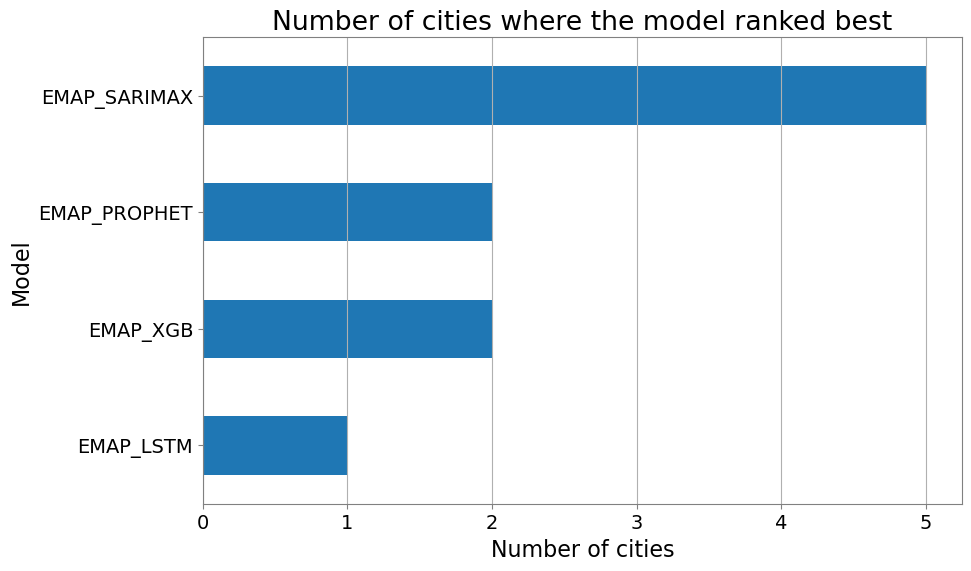

In [22]:
barplot_best_models(
    df_bm_st,
    challenge=challenge,
    model_col="best_model",
    xlabel="Number of cities",
    ylabel="Model",
    title="Number of cities where the model ranked best",) 

### Models with mean ratio >1 

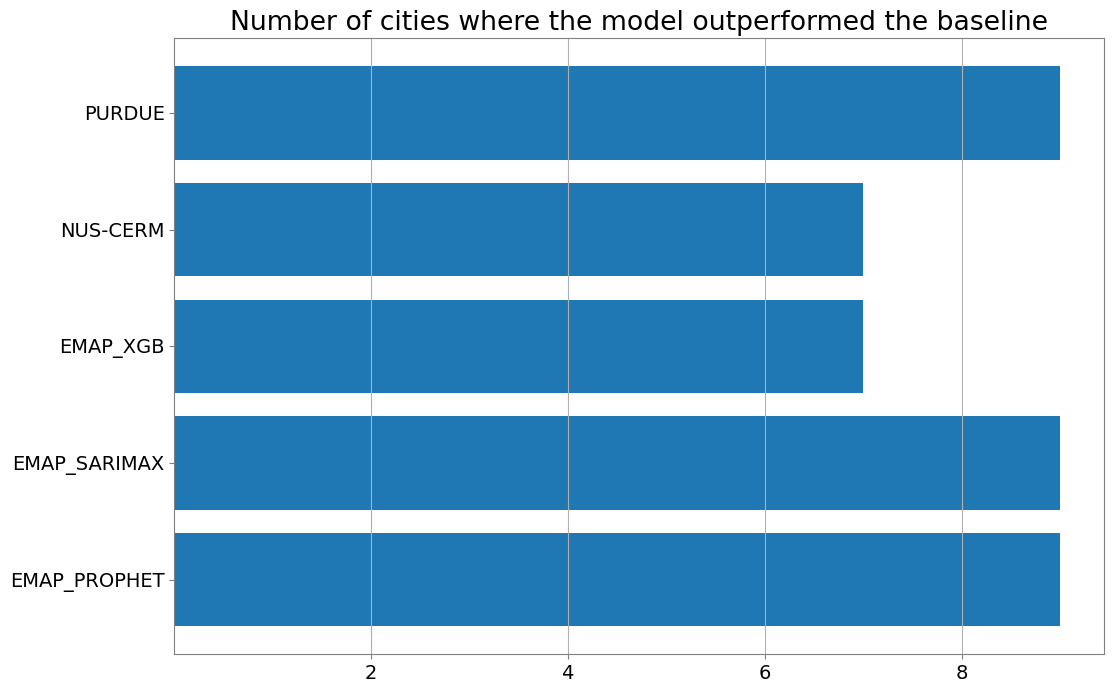

In [23]:
df_agg = df_summary.loc[ (df_summary.model != 'EMAP_LSTM')].loc[df_summary.geometric_mean_ratio < 1].groupby(['model'])[['adm_2_name']].count()

_, ax= plt.subplots(figsize = (12, 8))

ax.barh(df_agg.index, df_agg.adm_2_name)

ax.grid(axis = 'x')
ax.set_title('Number of cities where the model outperformed the baseline')
ax.set_xticks(np.arange(2, 10, step = 2))

plt.savefig(f'figures/n_cities_out_base_by_model_{challenge}.png', dpi = 300, bbox_inches = 'tight')

plt.show()

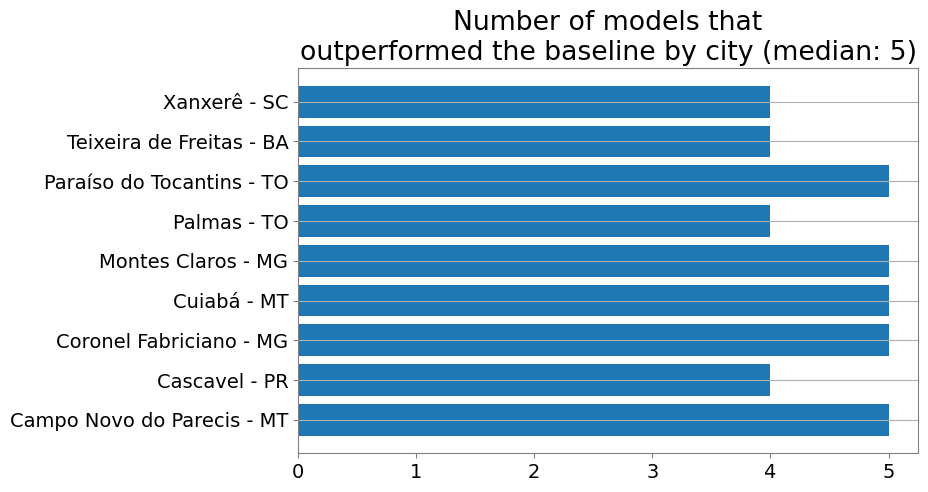

In [24]:
df_agg = df_summary.loc[ (df_summary.model != 'EMAP_LSTM')].loc[df_summary.geometric_mean_ratio < 1].groupby(['adm_2_name'])[['model']].count().reset_index()
df_agg['adm_2_name'] = df_agg['adm_2_name'].replace(code_to_state)

# Cria a coluna de região e ordena

# Plotagem
_, ax = plt.subplots(figsize=(8, 5))
ax.barh(df_agg.adm_2_name, df_agg.model)
ax.set_title(f'Number of models that\noutperformed the baseline by city (median: {int(np.median(df_agg.model))})')

ax.grid(axis='y')

plt.savefig(f'figures/n_models_out_base_by_city_{challenge}.png', dpi = 300,  bbox_inches = 'tight')

### Zoom: 

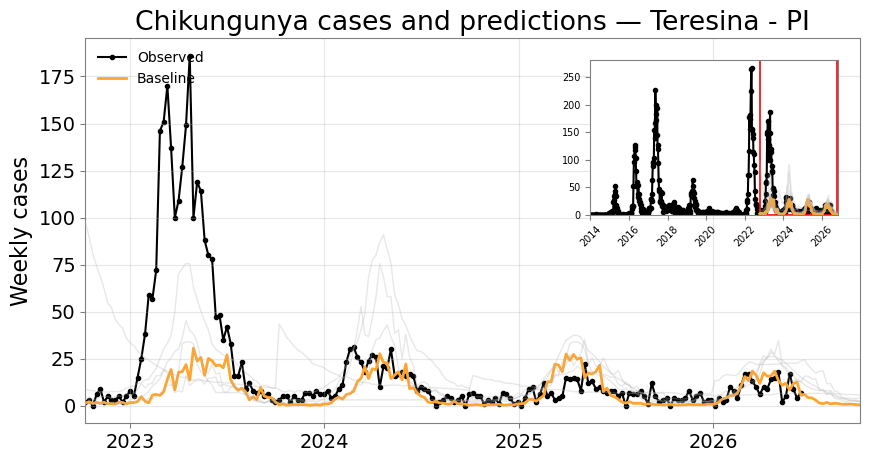

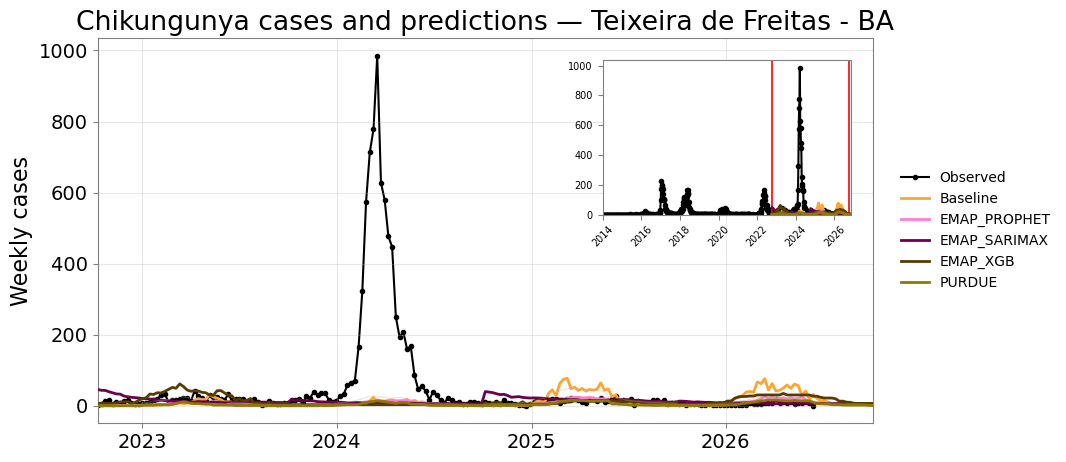

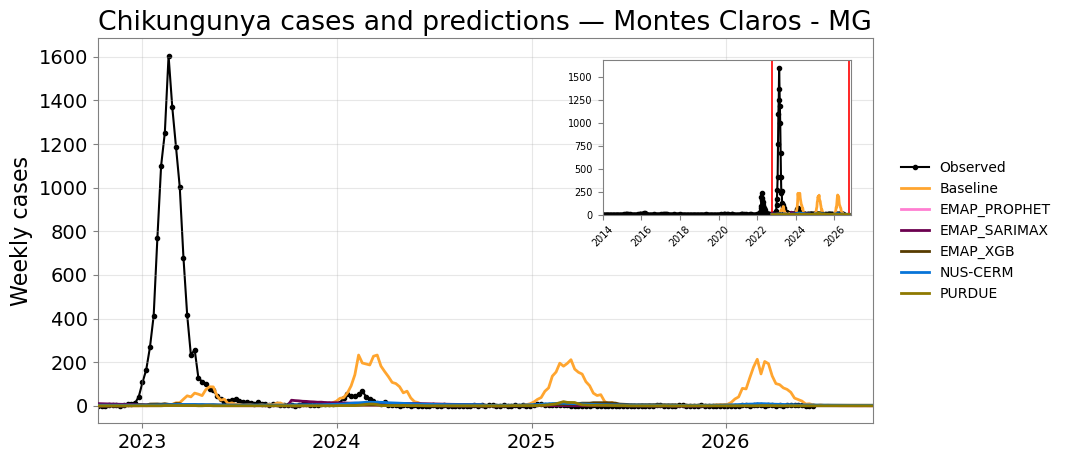

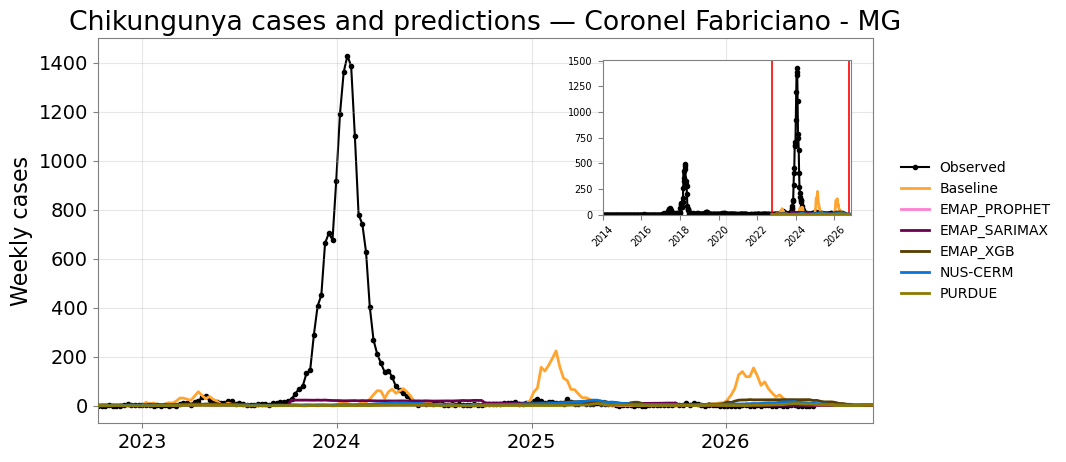

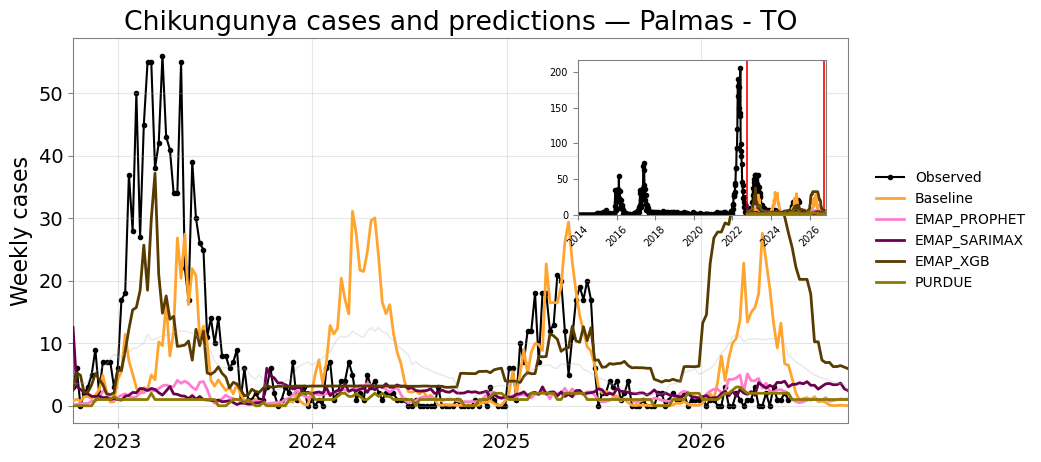

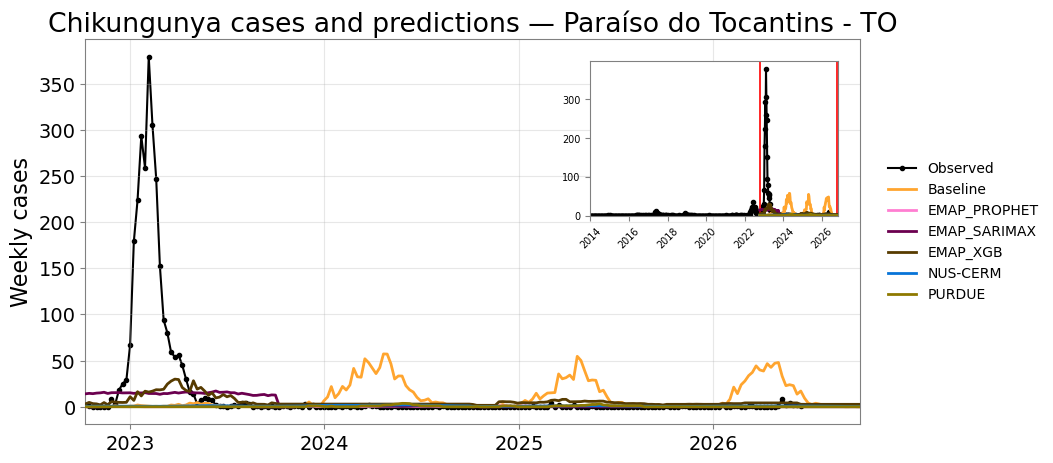

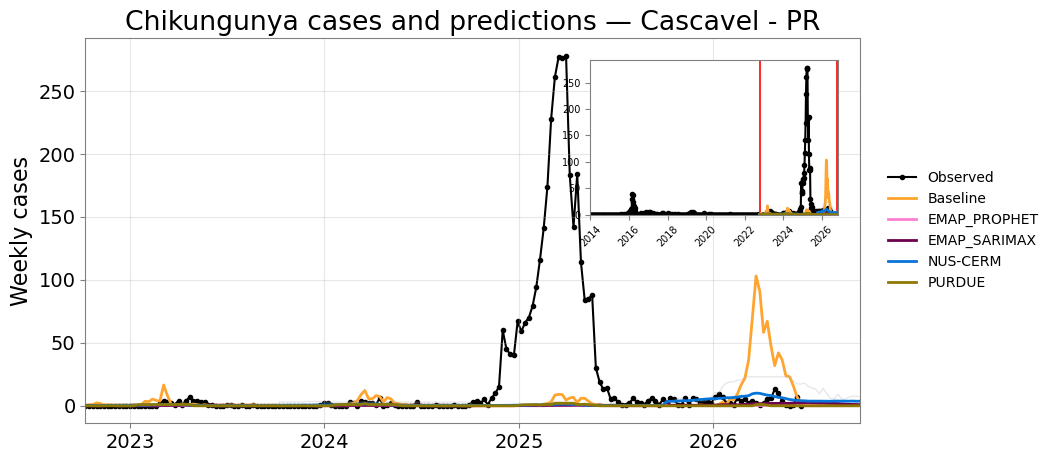

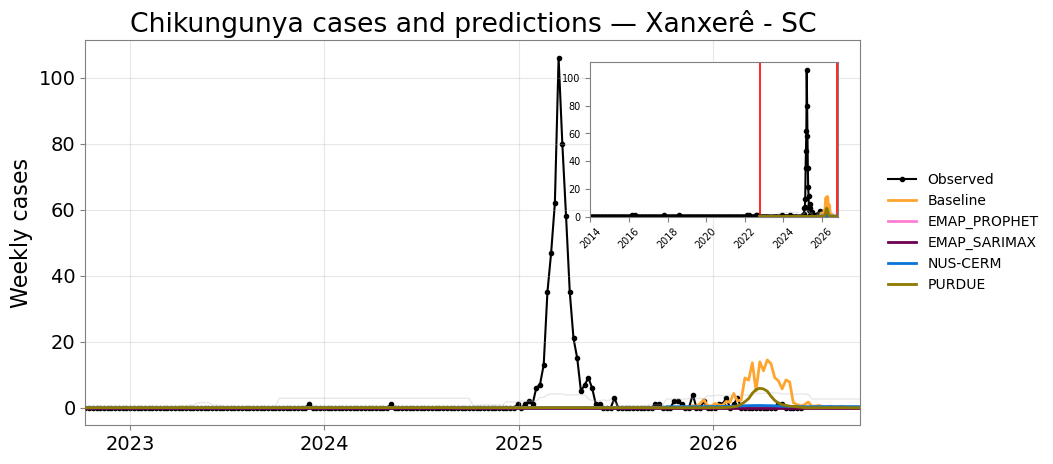

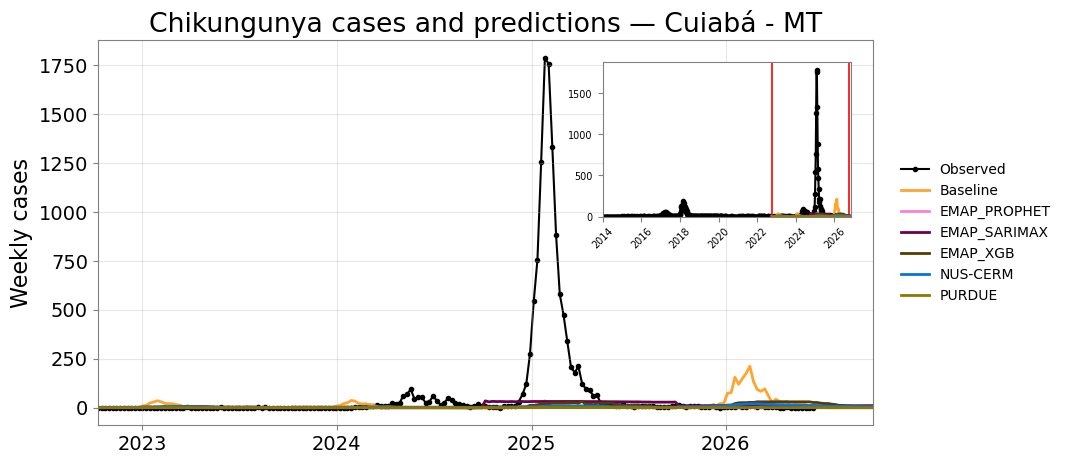

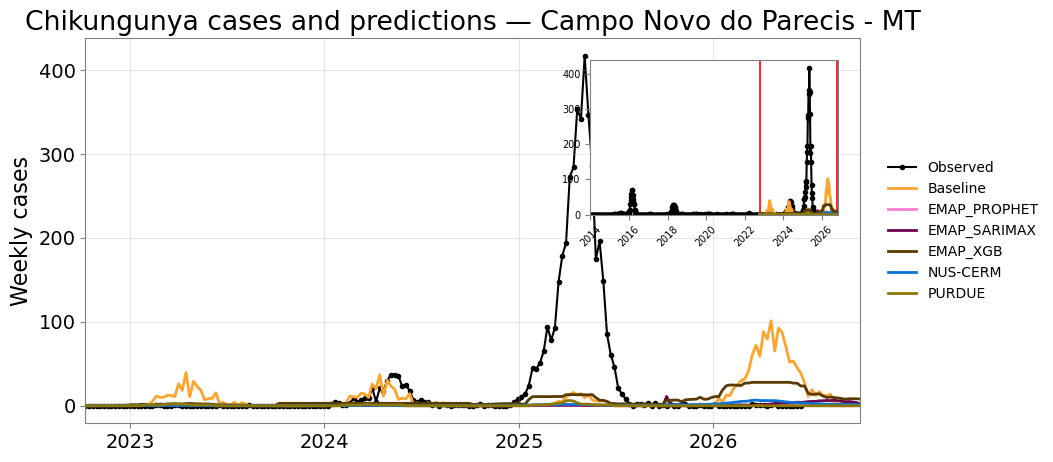

In [25]:
zoom_start = pd.to_datetime(Week(2022,41).startdate())
zoom_end = pd.to_datetime(Week(2026,40).startdate())


for geocode in df_preds.adm_2.unique(): 
    gname = df_summary.loc[df_summary.adm_2 == geocode]['adm_2_name'].values[0]
    plot_zoom_city(
        geocode,
        df_dengue,
        df_preds,
        df_summary,
        gname,
        color_palette,
        zoom_start,
        zoom_end,
        model_base="EMAP_LSTM",
        figsize=(10, 5),
        savepath=f'figures/zoom_{geocode}_{challenge}.png',
        disease='chikungunya'
        )

    plt.show()
    plt.close()

### Rankplots: 

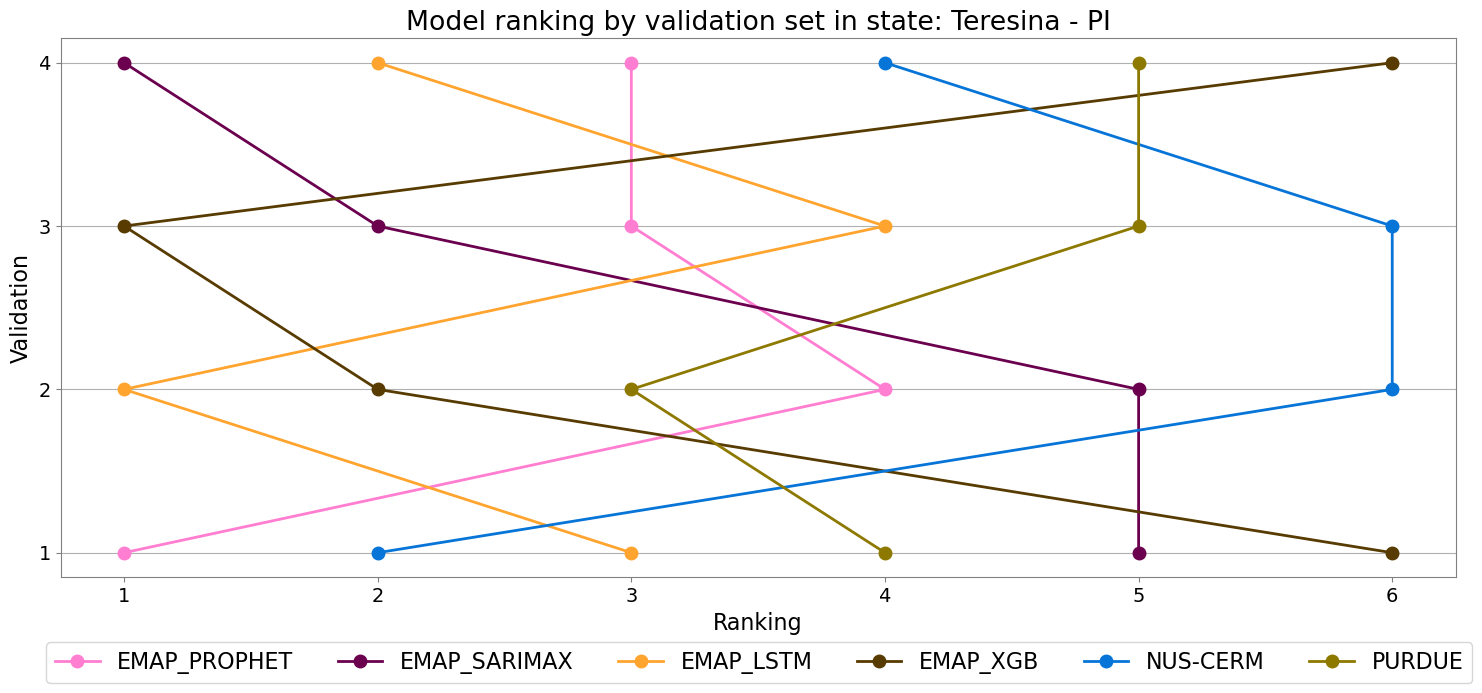

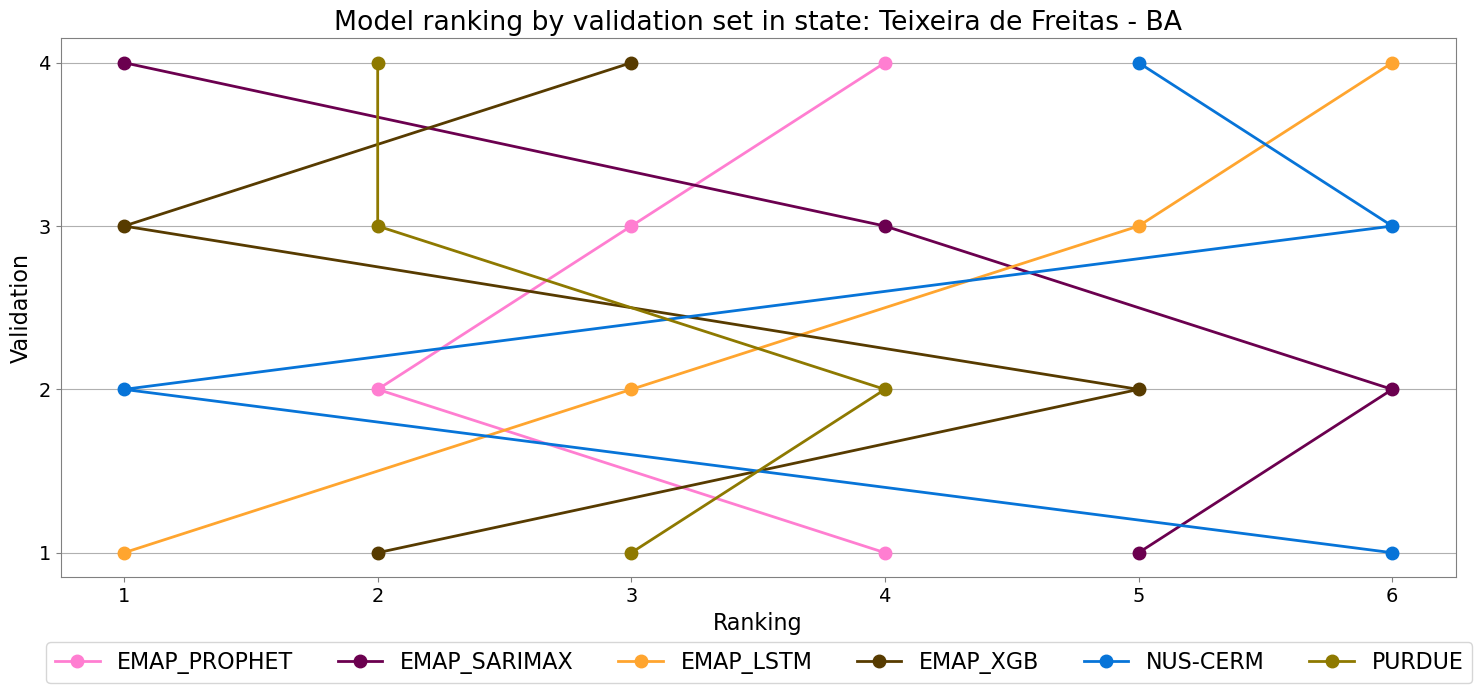

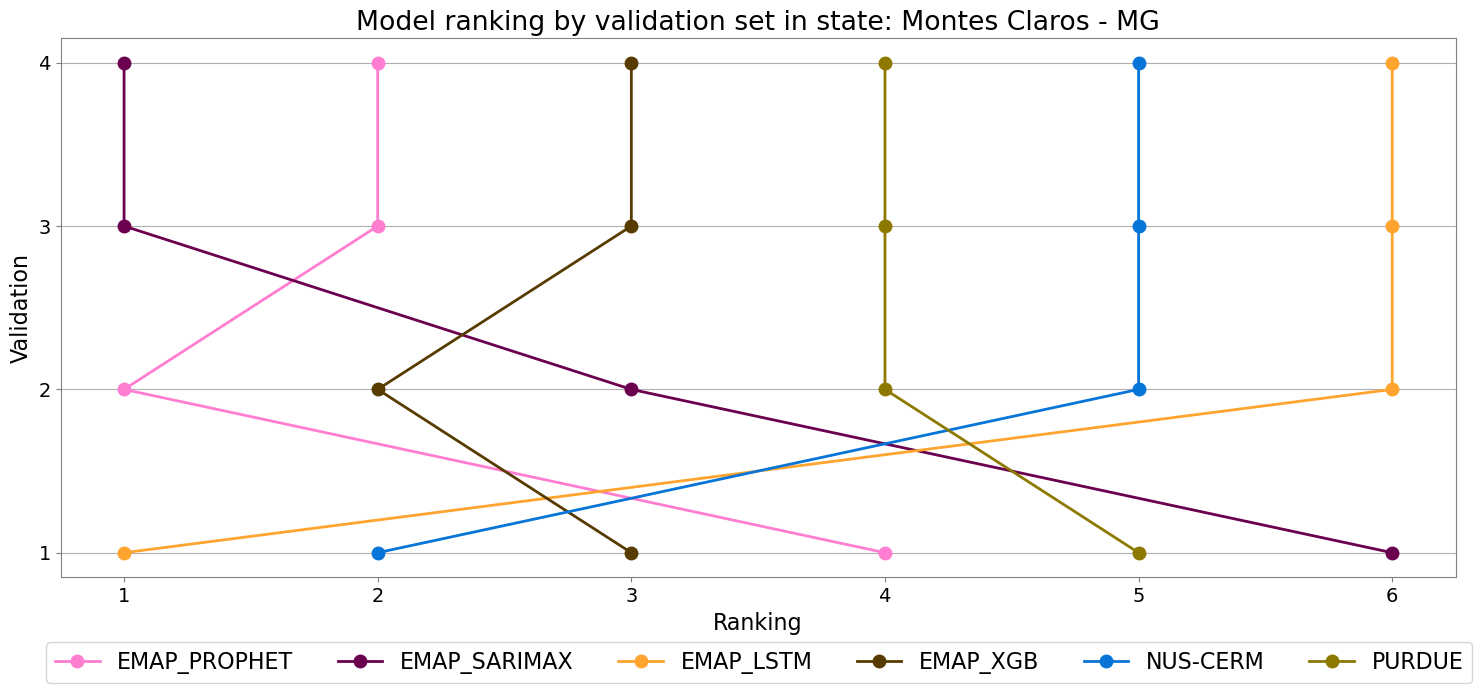

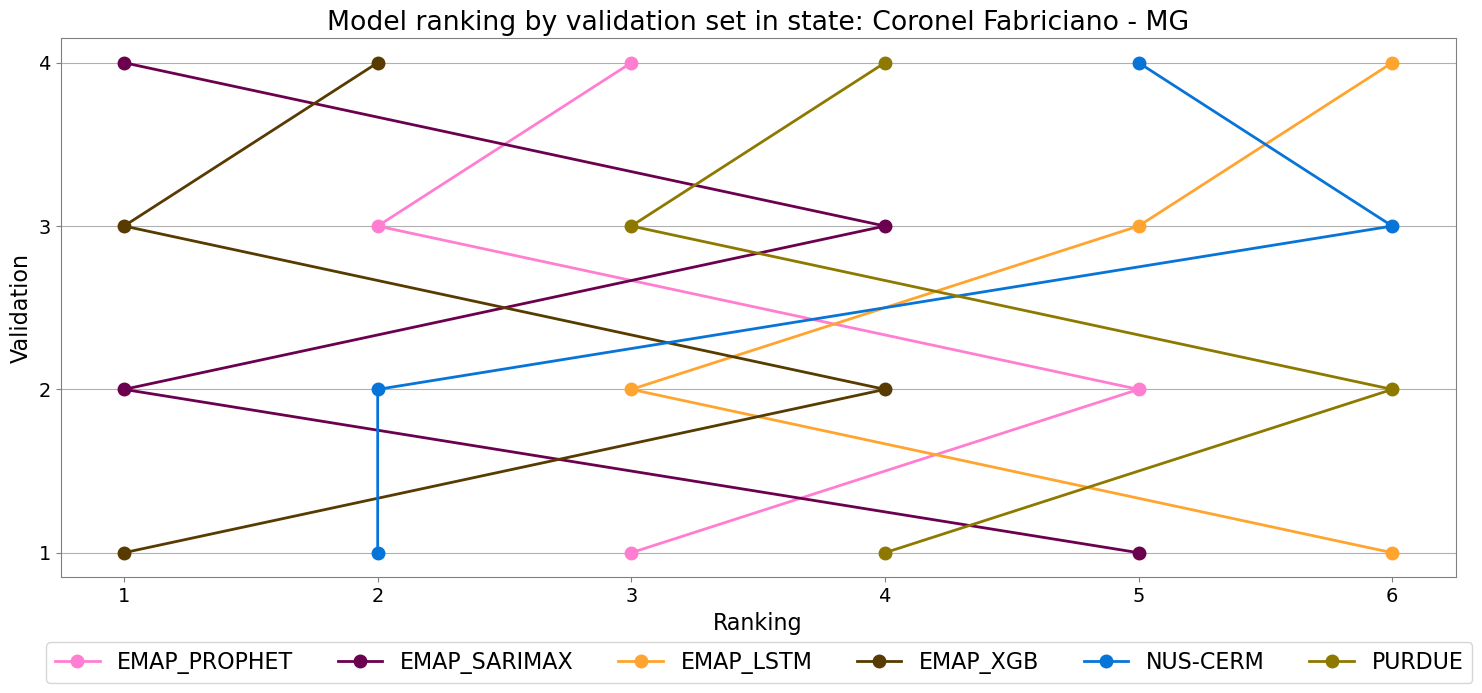

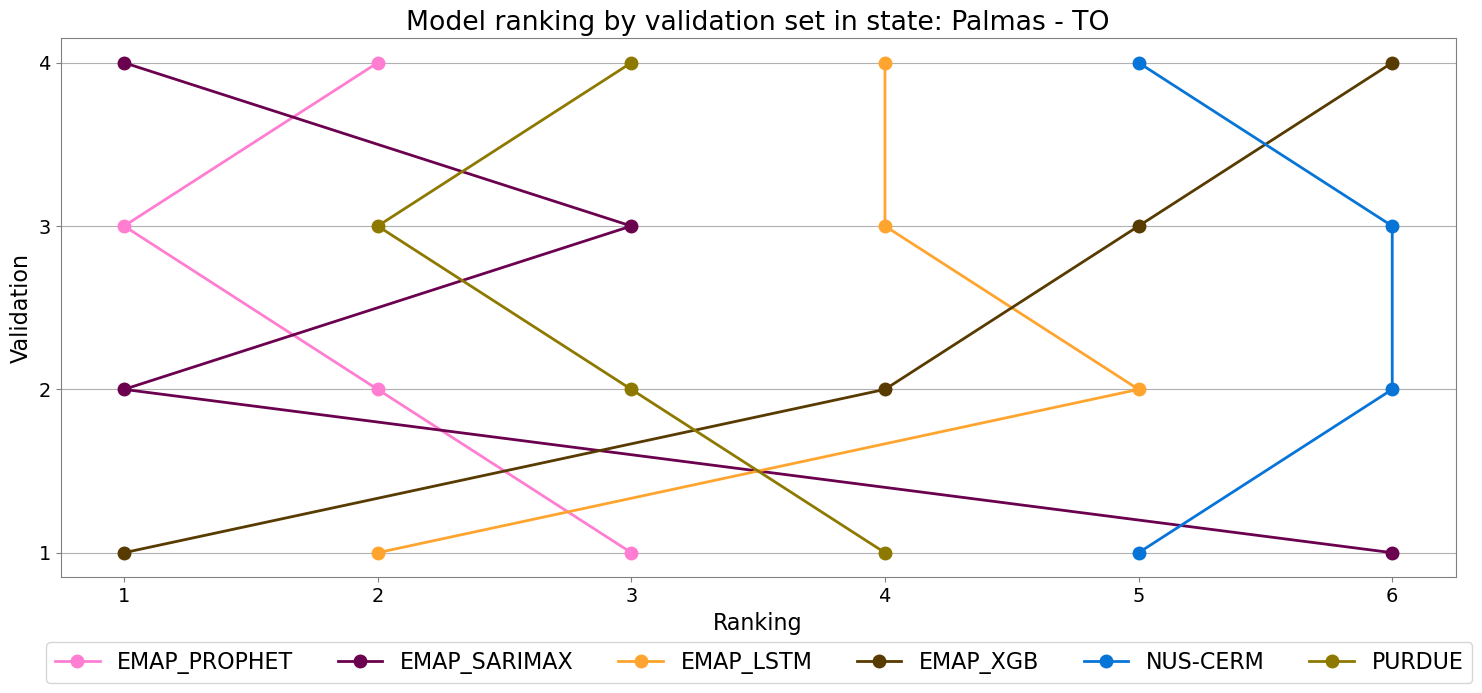

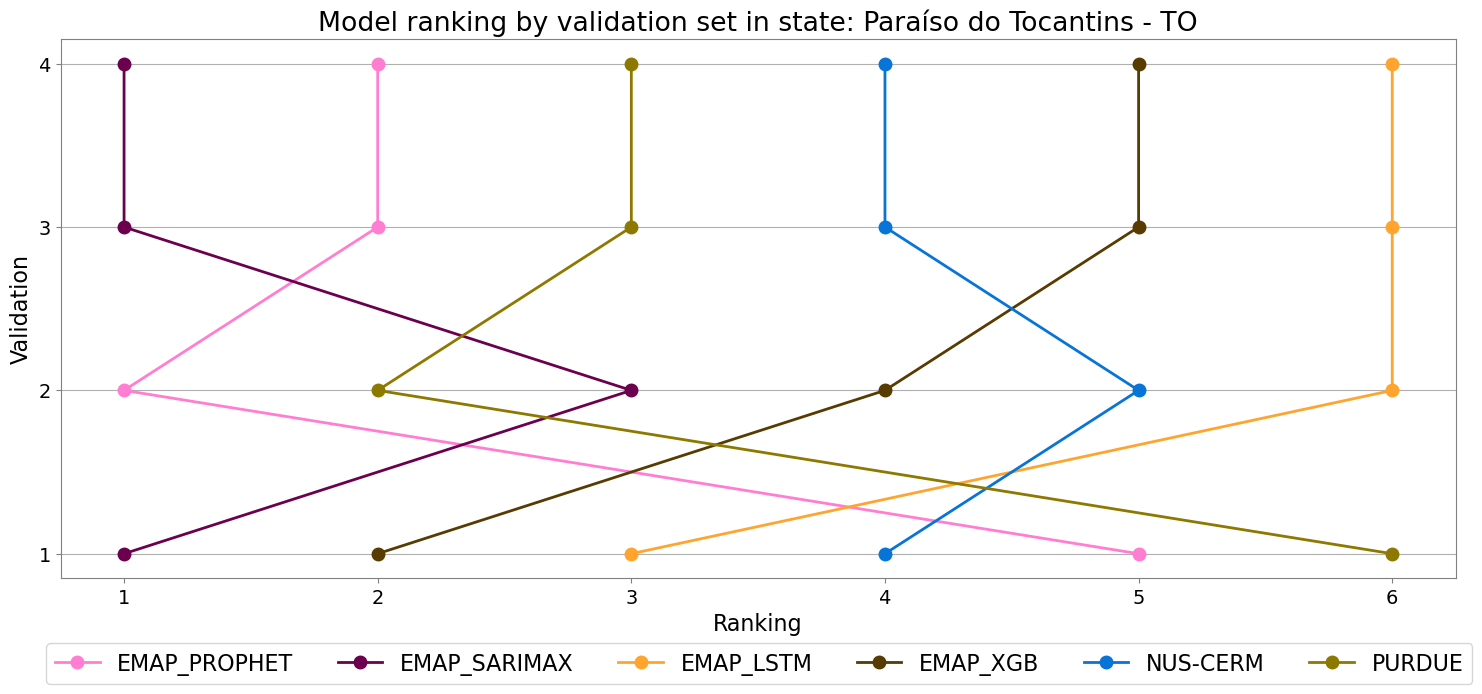

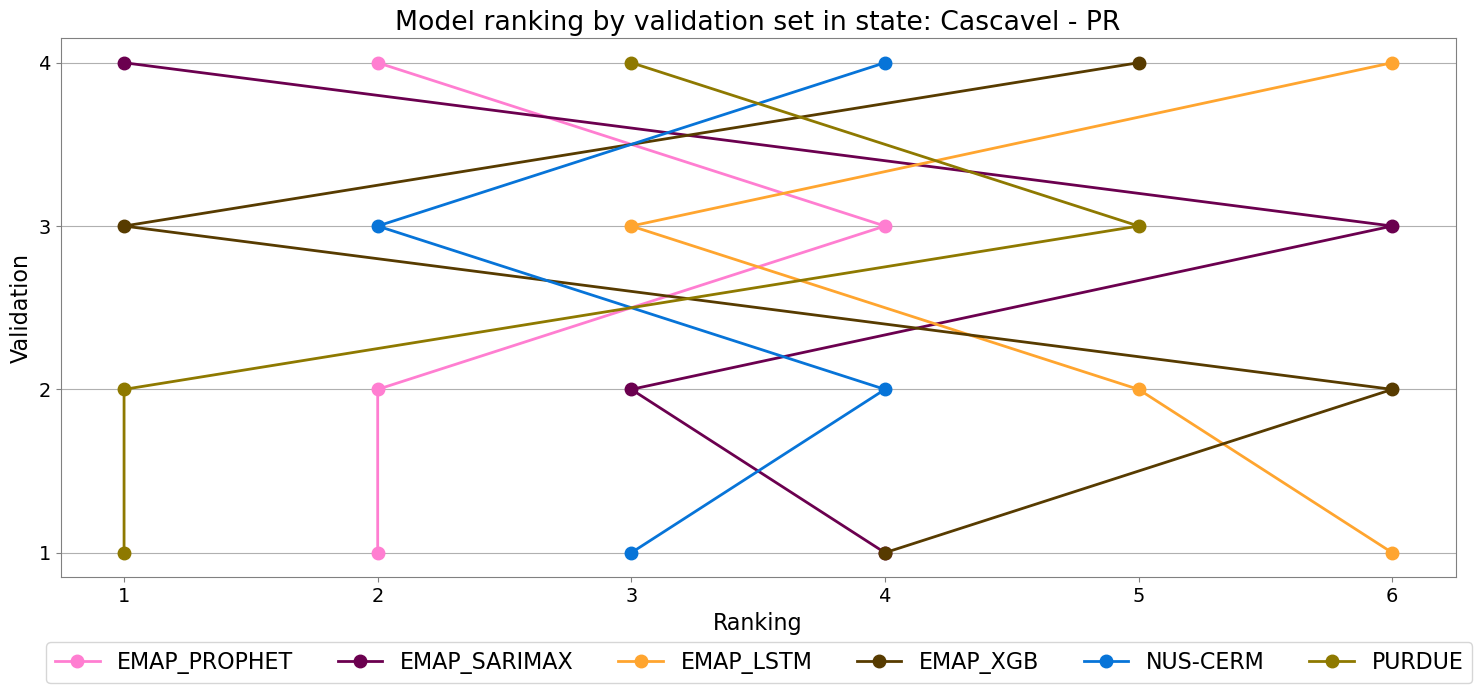

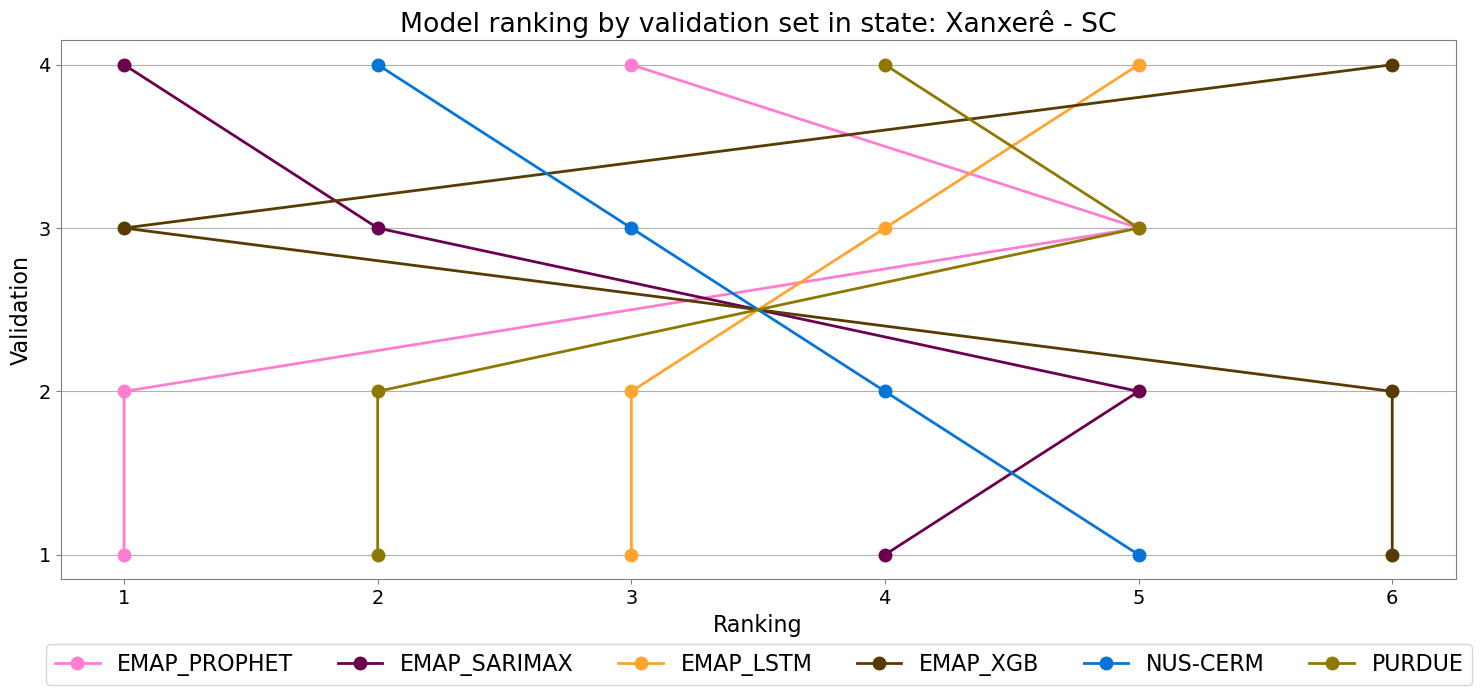

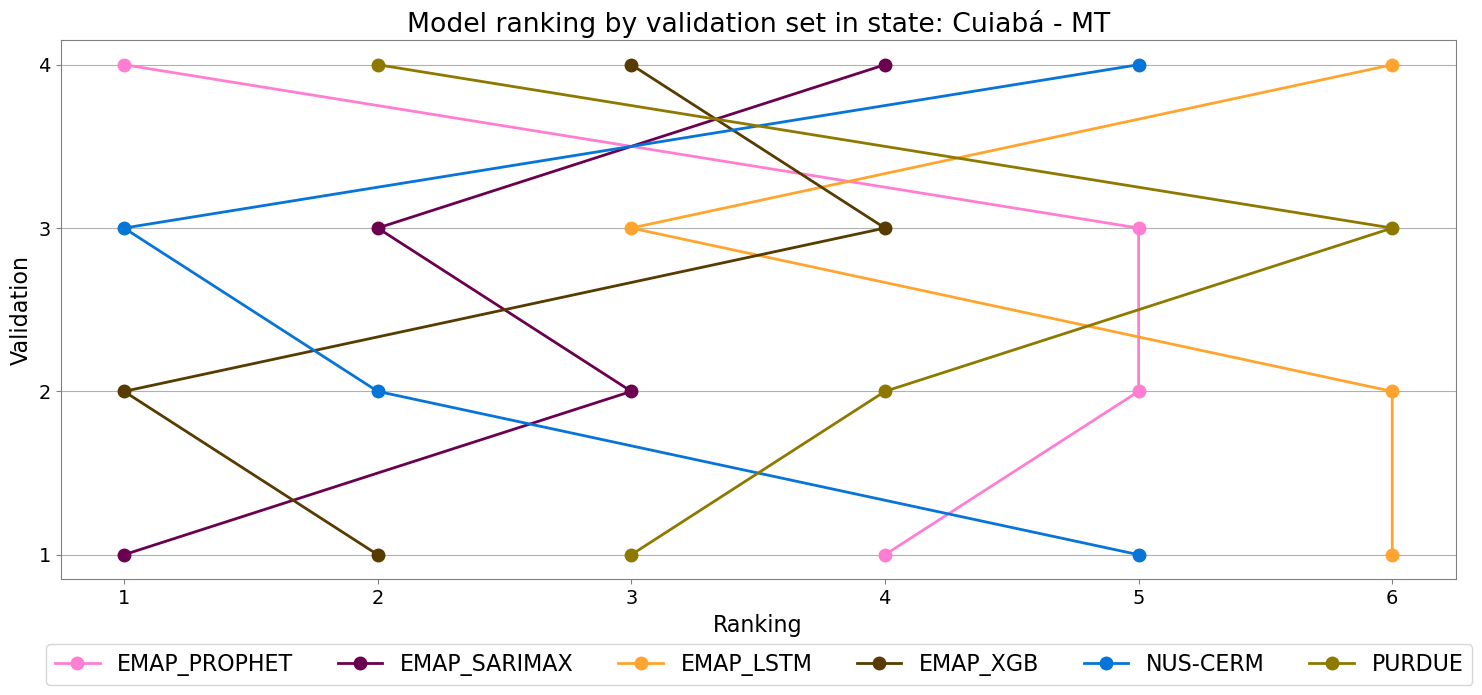

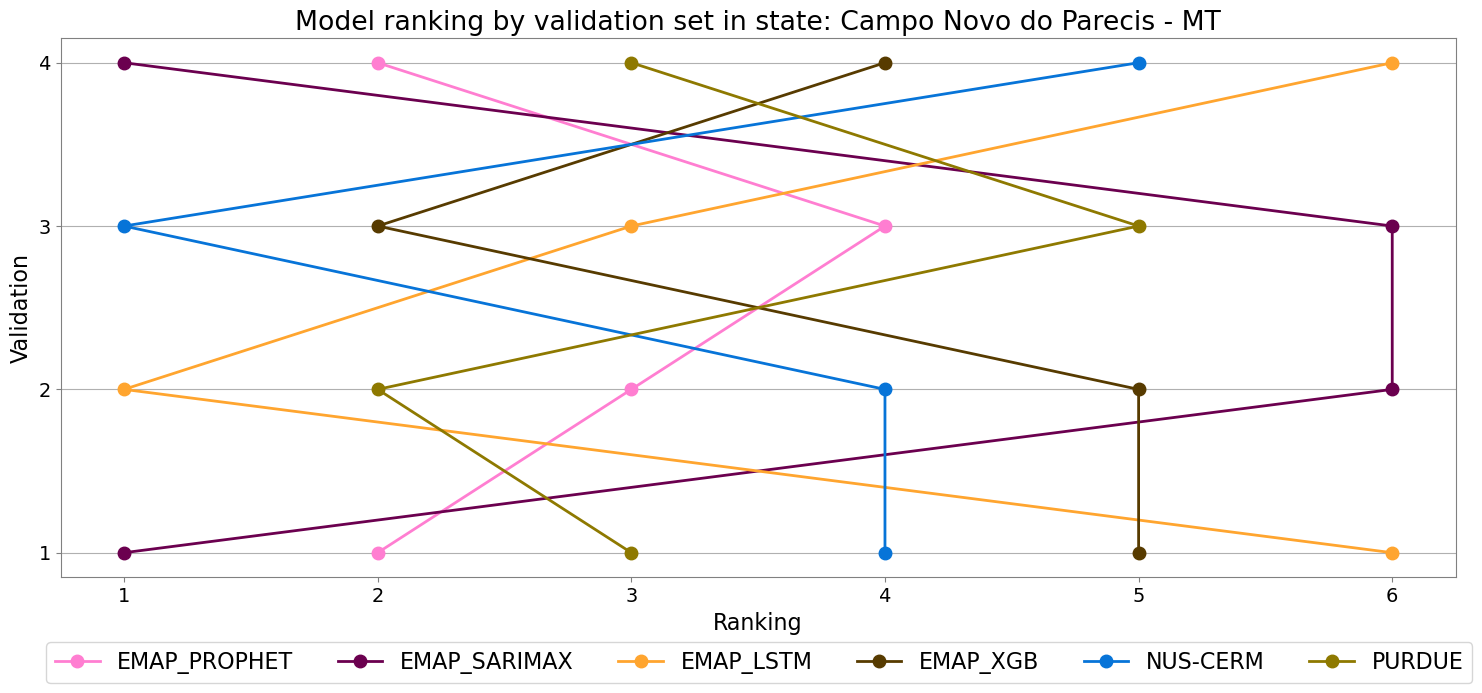

In [26]:
for geocode in df_preds.adm_2.unique(): 

    gname = df_summary.loc[df_summary.adm_2 == geocode]['adm_2_name'].values[0]

    plot_rankplot(
        df=df_rank,
        colors=color_palette,
        x_col="rank",
        x_label="Ranking",
        title="Model ranking by validation set",
        region=geocode,
        x_ticks=np.arange(1, 7),
        x_lim=None,
            ncols_legend=6,
            bbox_to_anchor=(1.02, -0.1), 
            challenge = challenge,
    region_col = 'adm_2',
    region_name = gname    )


### Comp distributions - max cases, peak cases and peak height:

In [27]:
df_true_params = pd.read_csv(f'data/parameters_{challenge}.csv.gz')

df_true_params.head()

,adm_2,validation,peak_week,total_cases,peak_height,peak_height_model,t_ini
0,2211001,1,26.773545,2498,186,157.779925,8
1,2211001,2,26.475594,580,31,25.682601,1
2,2211001,3,30.503500,345,22,11.509380,1
3,2211001,4,26.917865,264,18,12.115310,1
4,1721000,1,25.237435,994,56,50.398341,1


In [28]:
df_pars = pd.read_csv(f'predictions/new_metrics_{challenge}_new.csv.gz')
df_pars['model'] = df_pars['model'].replace(rename_models)
df_pars.head()

,model,validation,adm_2,season_total_p25,season_total_p50,season_total_p975,season_peak_p25,season_peak_p50,season_peak_p975,r0_dist_p25,...,r0_dist_p975,pico_dist_p25,pico_dist_p50,pico_dist_p975,t_ini_dist_p25,t_ini_dist_p50,t_ini_dist_p975,max_c_dist_p25,max_c_dist_p50,max_c_dist_p975
0,NUS-CERM,2,2211001,353.830268,2833.000235,33191.360158,46.514525,483.576746,10521.032326,1.064037,...,3.037212,5.000000,28.775718,35.0,1.0,9.0,23.525,16.722719,174.493104,2019.424886
1,NUS-CERM,3,2211001,351.395005,1634.353183,12931.802840,56.644229,402.463697,7754.465519,1.051483,...,2.833496,8.761160,29.850181,35.0,1.0,3.5,25.150,11.988801,85.811525,774.128582
2,NUS-CERM,4,2211001,344.322826,1462.564773,9378.880753,65.249936,432.841958,6269.227284,1.072877,...,3.387402,11.128405,29.595326,35.0,1.0,4.0,25.575,12.636685,57.041438,1130.038779
3,EMAP_LSTM,2,2211001,195.504772,831.801992,4340.746010,23.990344,157.778181,1351.790328,1.066425,...,3.084869,10.360514,27.362884,35.0,1.0,6.5,22.000,6.730808,49.981303,401.265060
4,EMAP_LSTM,3,2211001,432.217153,1155.052973,3764.039399,68.035110,266.692085,2155.108063,1.077653,...,2.677095,17.068076,27.634045,35.0,1.0,4.0,20.000,15.623541,59.711376,355.585775


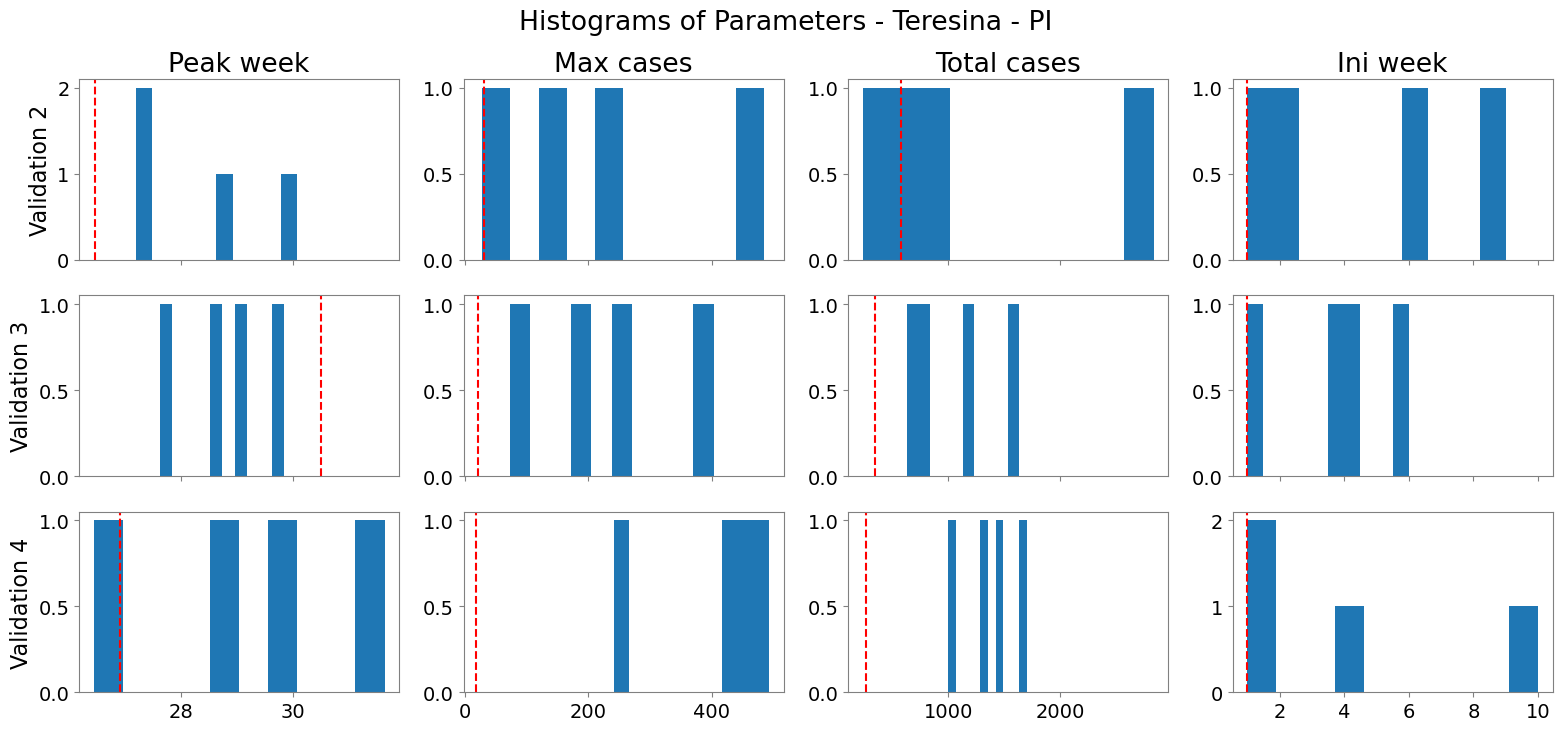

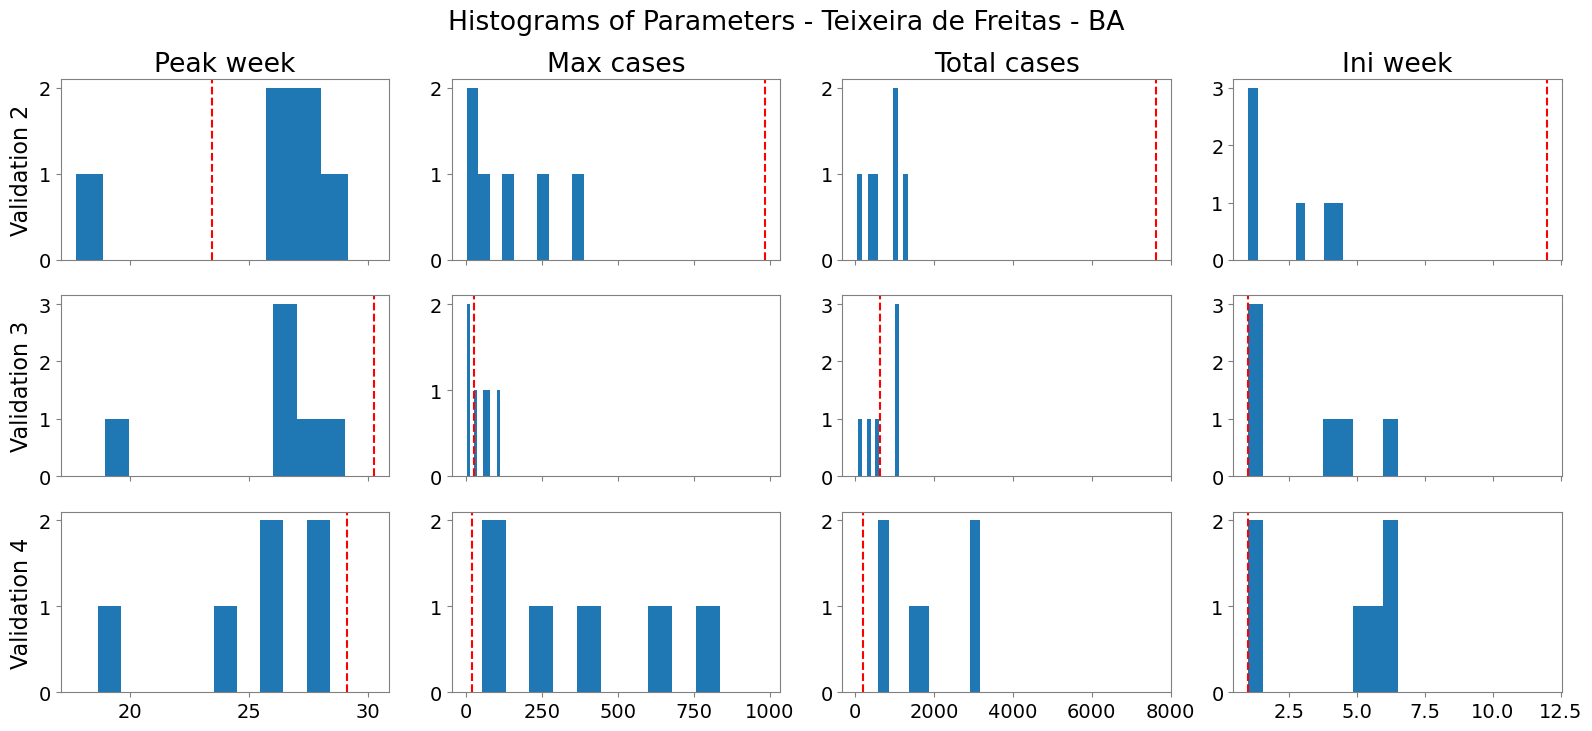

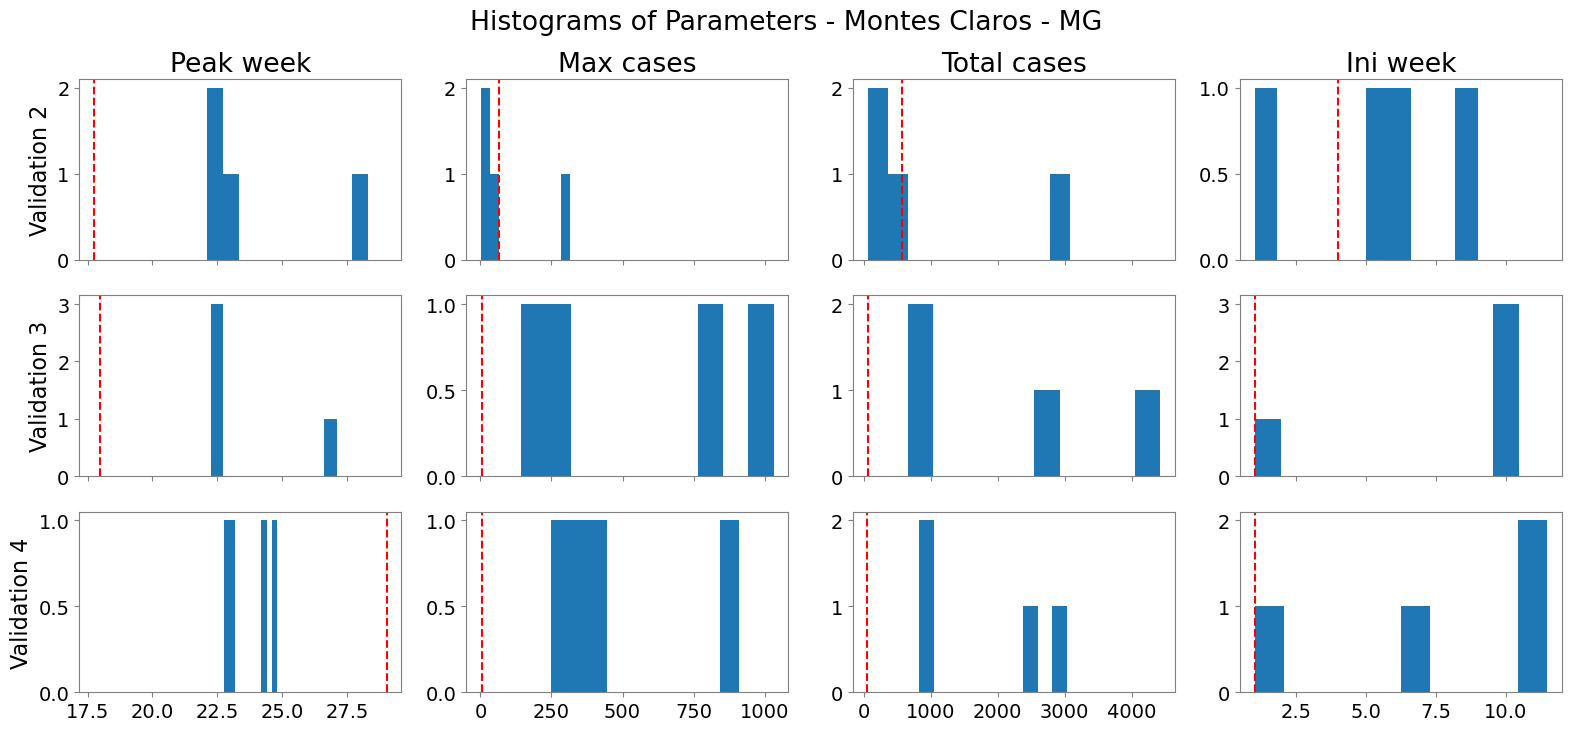

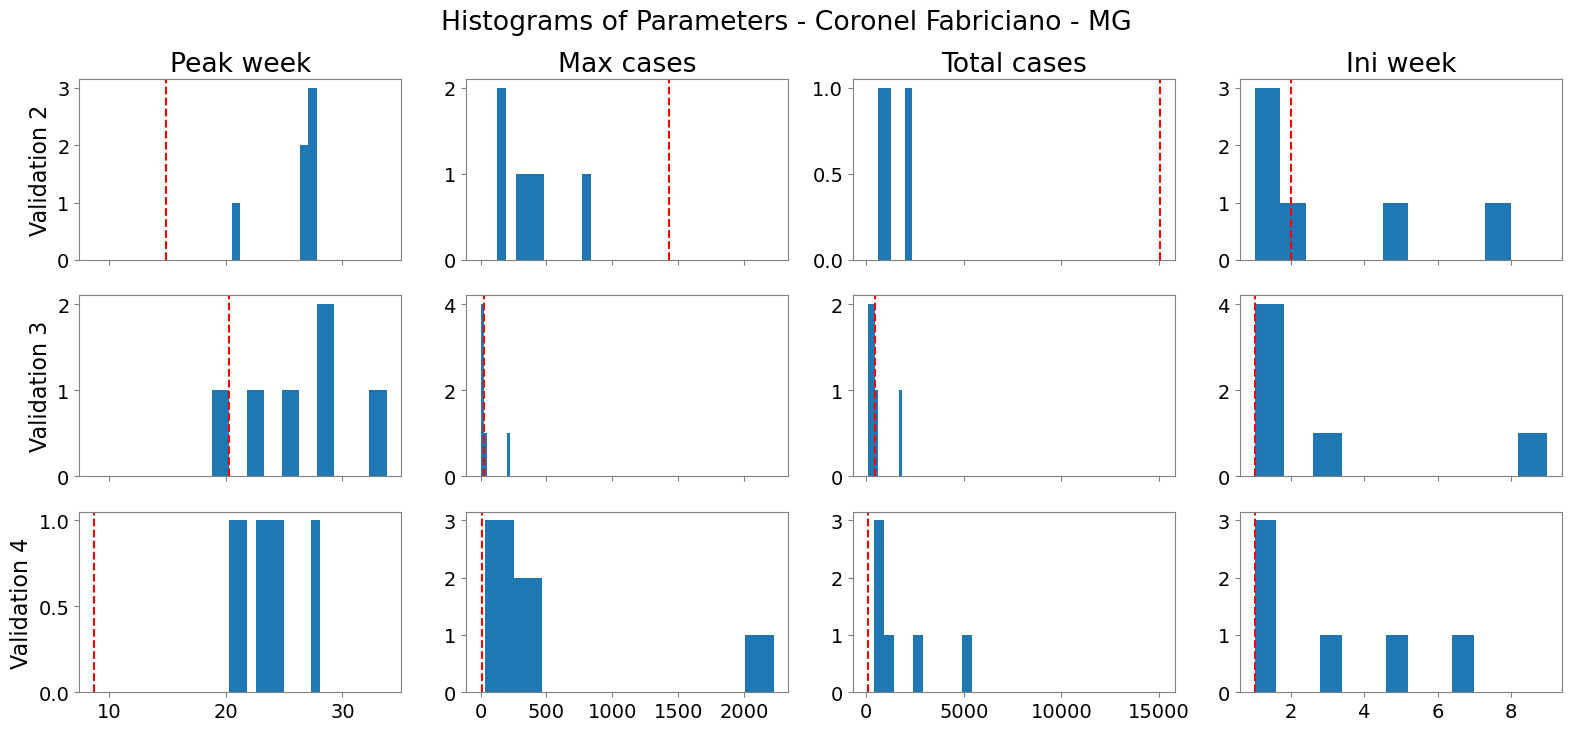

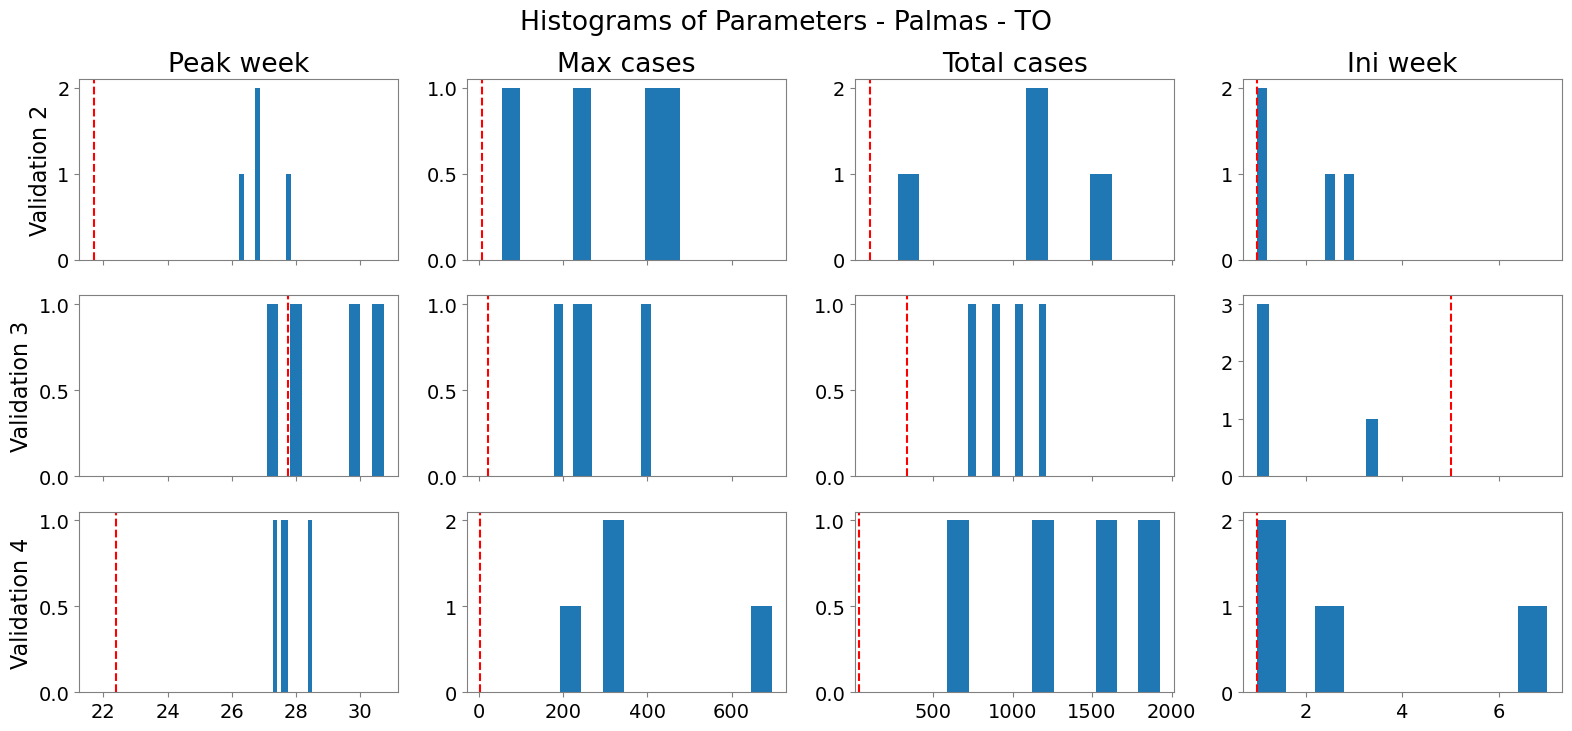

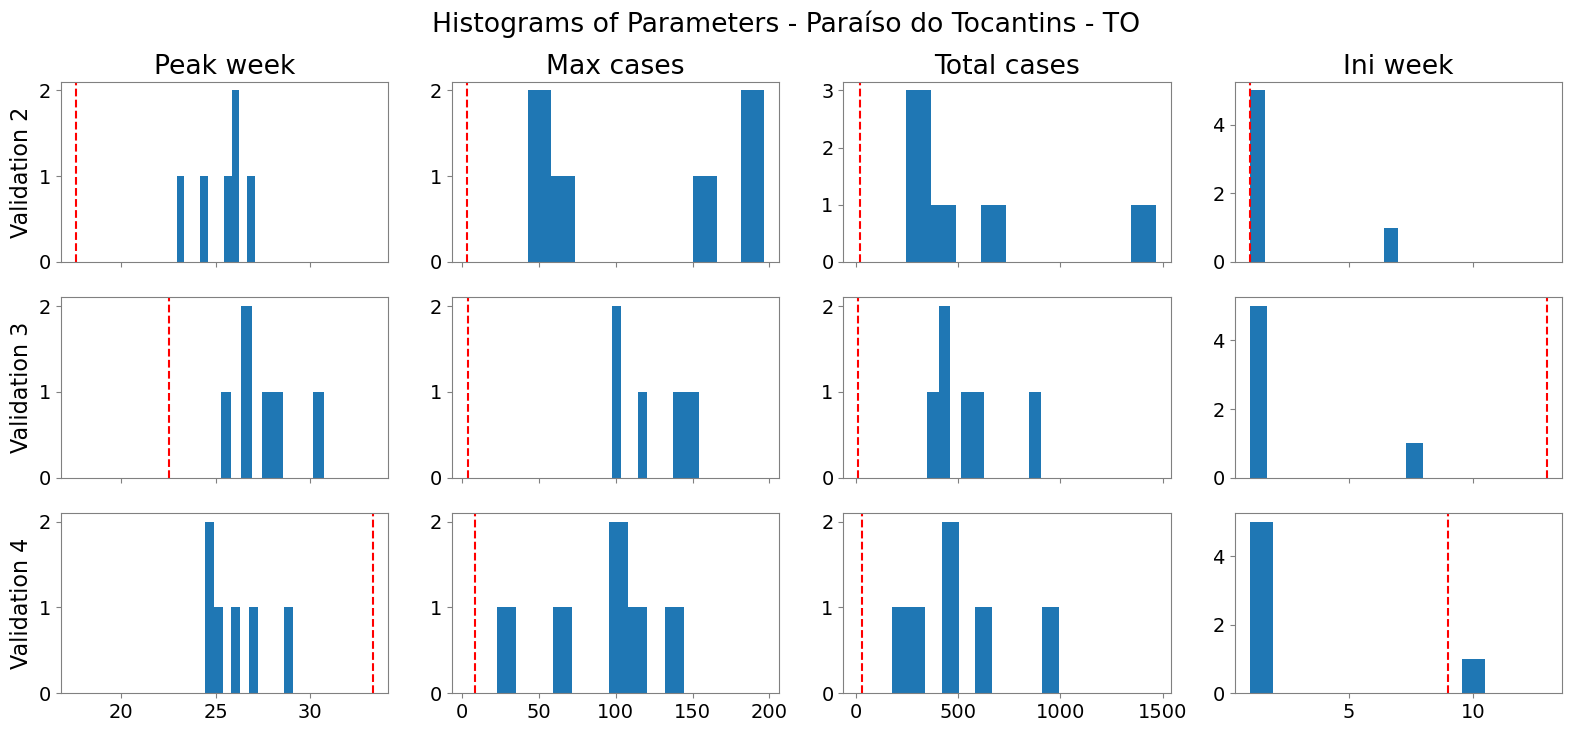

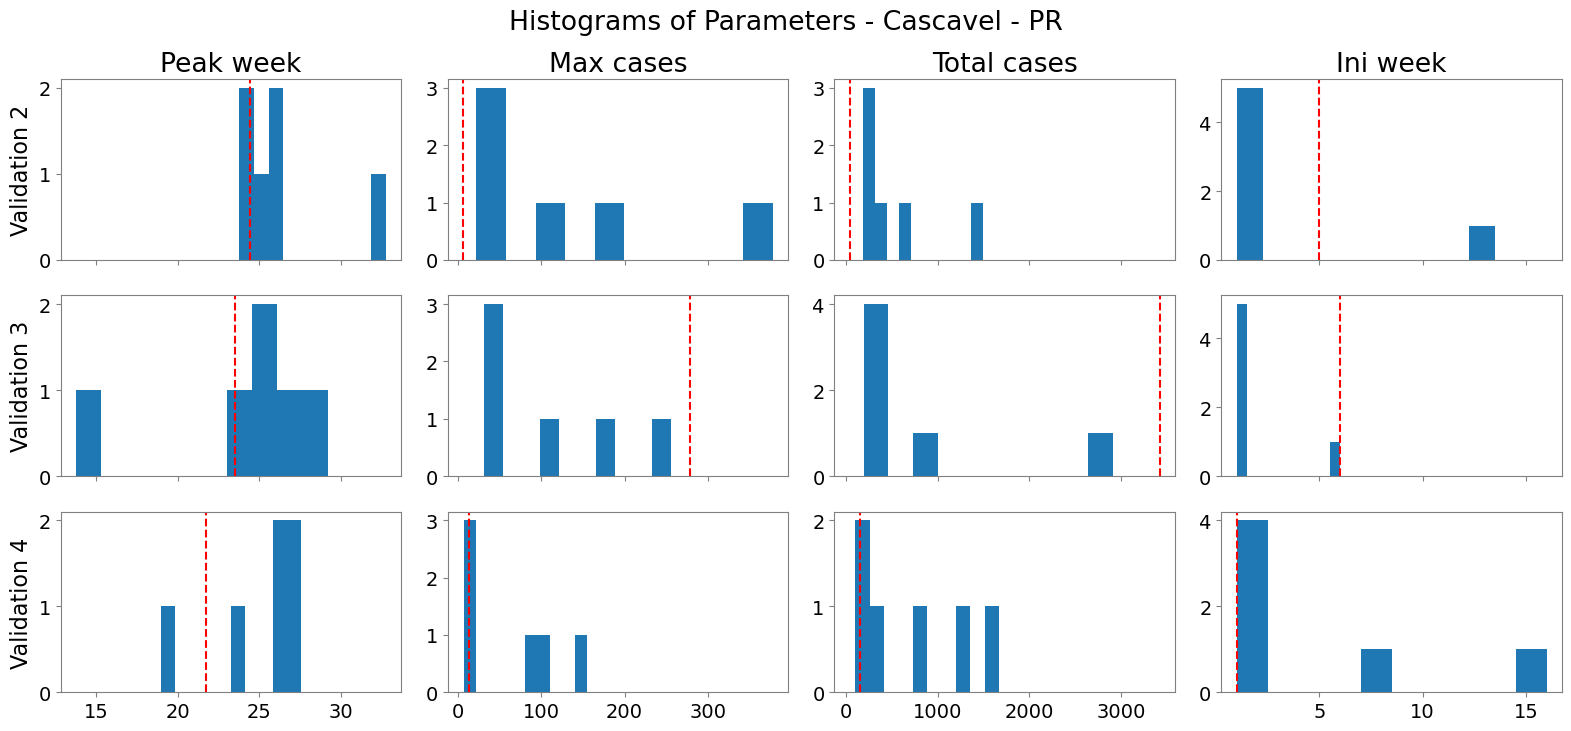

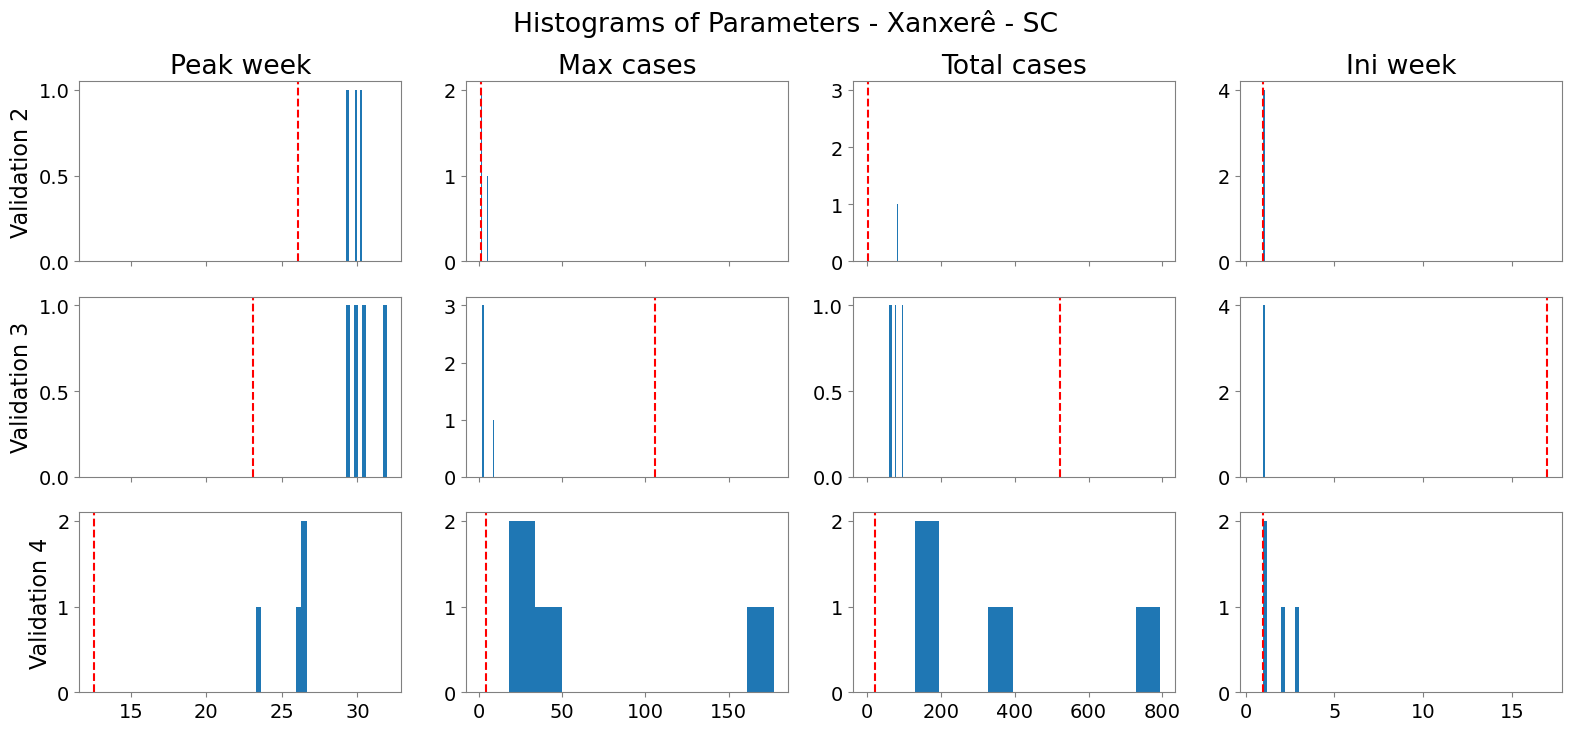

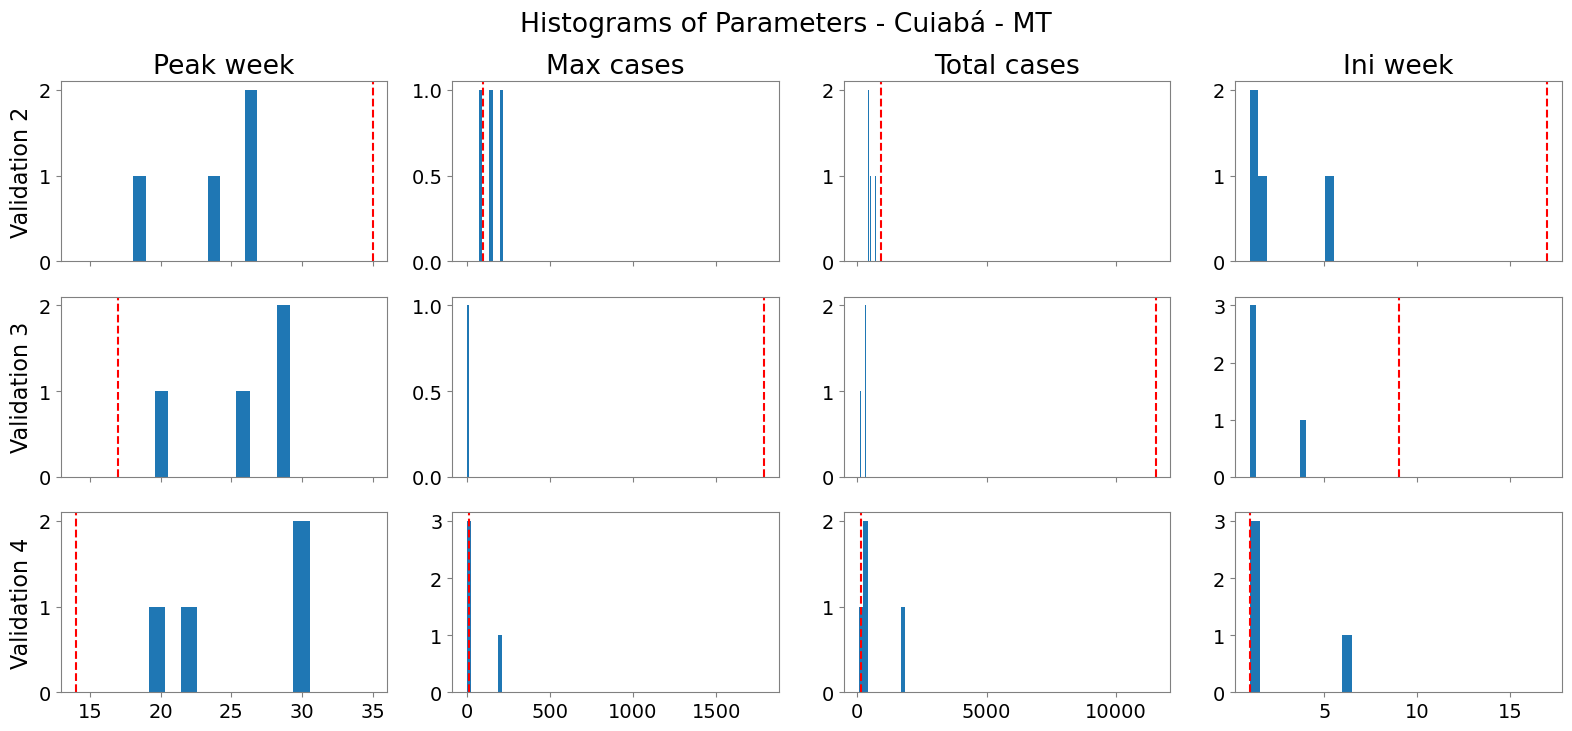

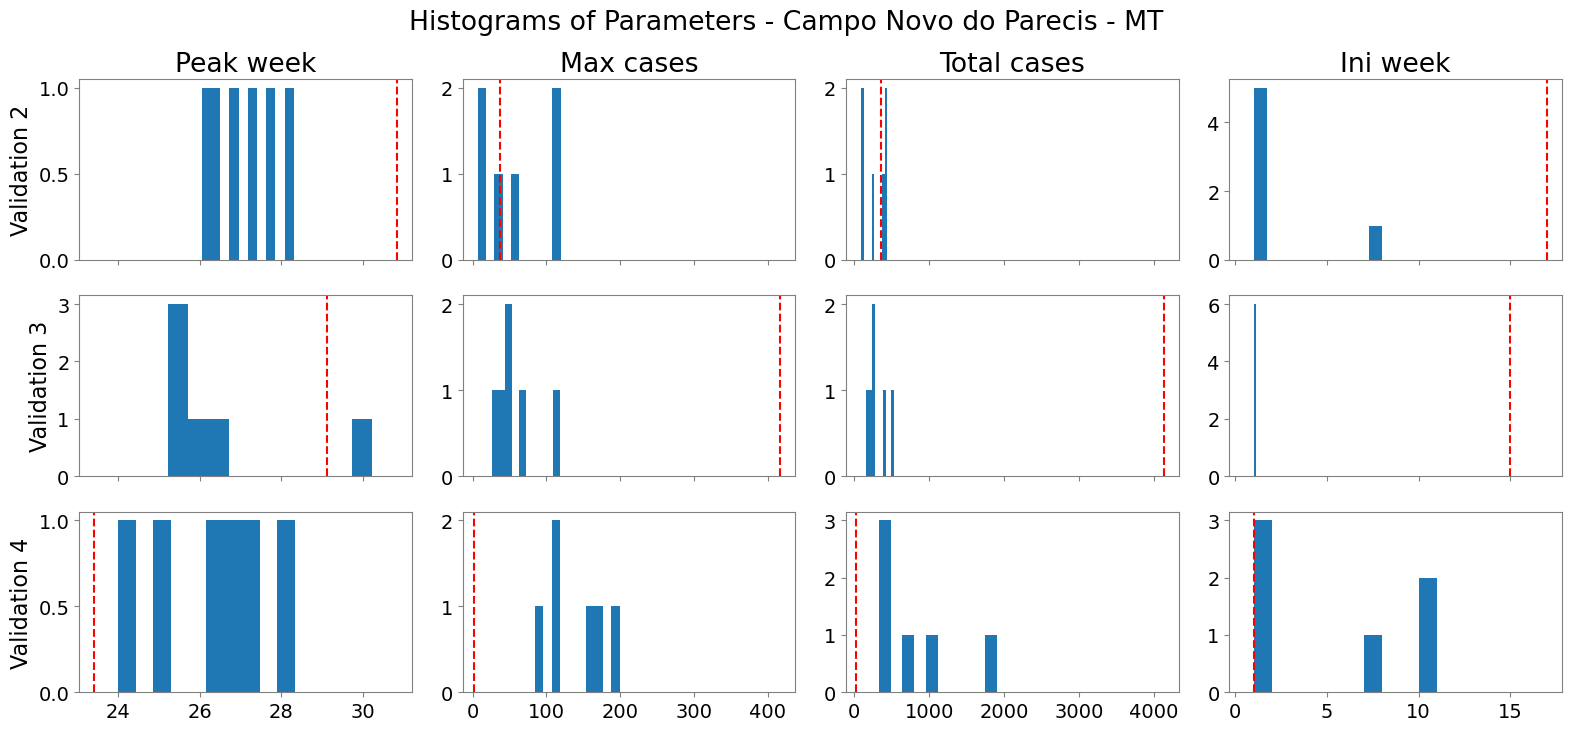

In [29]:
for geocode in df_preds.adm_2.unique():

    gname = df_summary.loc[df_summary.adm_2 == geocode]['adm_2_name'].values[0]


    fig, ax = plot_parameter_histograms(df_true_params,
        df_pars,
        region =geocode, label_title=gname, col_region = 'adm_2')
    
    plt.savefig(f'figures/hist_pars_{geocode}_{challenge}.png', dpi = 400, bbox_inches = 'tight')
    